# 5th Year MS Technical Report RQ2

**NOTE:** Code is implemented with the assumption that each db stores a separate course and semester, and only the Ants project

## Setup

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import sqlite3
import json
from enum import Enum
import re
from collections import defaultdict
import os

In [2]:
class Term(Enum):
    SPRING = 0
    SUMMER = 1
    FALL = 2

    def __str__(self):
        return self.name.capitalize()

    def short_name(self):
        if self == Term.SPRING:
            return "sp"
        elif self == Term.SUMMER:
            return "su"
        else:
            return "fa"


class Course:
    cs61a: bool
    term: Term
    year: int

    def __init__(self, cs61a: bool, term: Term, year: int):
        self.cs61a = cs61a
        self.term = term
        self.term_string = term.short_name() + str(year)[2:]
        self.year = year

    def __str__(self):
        return f"{'CS 61A' if self.cs61a else 'DATA C88C'} {self.term} {self.year}"

    def __repr__(self):
        return f"Course(cs61a={self.cs61a}, term={repr(self.term)}, year={self.year})"

    def __eq__(self, other):
        if isinstance(other, Course):
            return (
                self.cs61a == other.cs61a
                and self.term == other.term
                and self.year == other.year
            )
        return NotImplemented

    def __hash__(self):
        return hash(str(self))

In [3]:
courses = []

for year in (2024, 2025):
    for term in (Term.SPRING, Term.SUMMER, Term.FALL):
        for cs61a in (True, False):
            courses.append(Course(cs61a, term, year))

courses = [
    Course(True, Term.FALL, 2023),
    Course(False, Term.FALL, 2023),
] + courses

assert len(courses) == 14

for c in courses:
    print(c)

CS 61A Fall 2023
DATA C88C Fall 2023
CS 61A Spring 2024
DATA C88C Spring 2024
CS 61A Summer 2024
DATA C88C Summer 2024
CS 61A Fall 2024
DATA C88C Fall 2024
CS 61A Spring 2025
DATA C88C Spring 2025
CS 61A Summer 2025
DATA C88C Summer 2025
CS 61A Fall 2025
DATA C88C Fall 2025


In [4]:
PATH_PREFIX = "../../data/private/out"


def get_db_cursor(course: Course) -> tuple[sqlite3.Connection, sqlite3.Cursor]:
    conn = sqlite3.connect(
        f"{PATH_PREFIX}/{'cs61a' if course.cs61a else 'datac88c'}/{course.term_string}/snapshots.db"
    )
    conn.row_factory = sqlite3.Row
    return conn, conn.cursor()

In [5]:
conns_curs = [get_db_cursor(course) for course in courses]
conns = [conn for conn, _ in conns_curs]
cursors = [cur for _, cur in conns_curs]

In [6]:
load_results = input("Would you like to load the existing results.json file? Y/N: ")
if load_results.strip().upper() == "Y":
    if os.path.exists("results.json"):
        with open("results.json") as f:
            results = json.load(f)
            print(f"Loaded metrics from results.json: {list(results.keys())}")
    else:
        print("results.json not found, defaulting to empty dict")
        results = {}
else:
    results = {}

In [7]:
# Assigning consistent colors: CS 61A (Blue/0), DATA C88C (Orange/1)
palette = sns.color_palette("colorblind")
course_colors = {"CS 61A": palette[0], "DATA C88C": palette[1]}

## How many backups are there per student?

In [8]:
def backups_per_student(cur: sqlite3.Cursor) -> np.array:
    cur.execute("SELECT COUNT(*) FROM backup_metadata GROUP BY student_email")
    return np.array([row[0] for row in cur.fetchall()])

In [9]:
results["backups_per_student"] = {}

for course, cur in zip(courses, cursors):
    results["backups_per_student"][course] = backups_per_student(cur)

<Axes: ylabel='Count'>

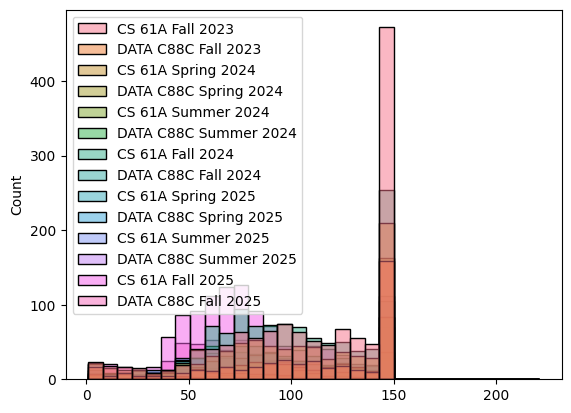

In [10]:
sns.histplot(data=results["backups_per_student"])

<Axes: ylabel='Count'>

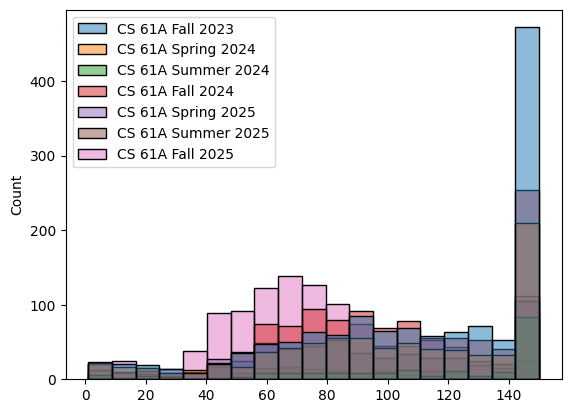

In [11]:
sns.histplot(
    data={key: val for key, val in results["backups_per_student"].items() if key.cs61a}
)

<Axes: ylabel='Count'>

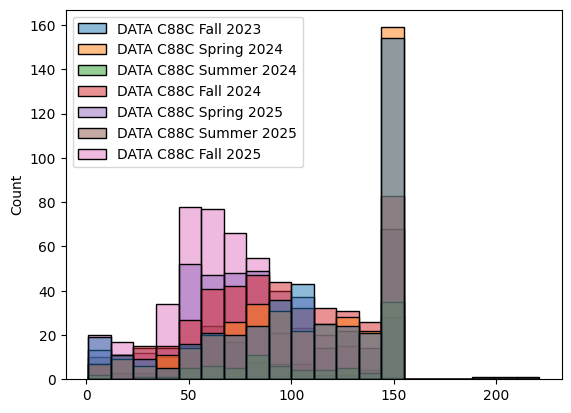

In [12]:
sns.histplot(
    data={
        key: val for key, val in results["backups_per_student"].items() if not key.cs61a
    }
)

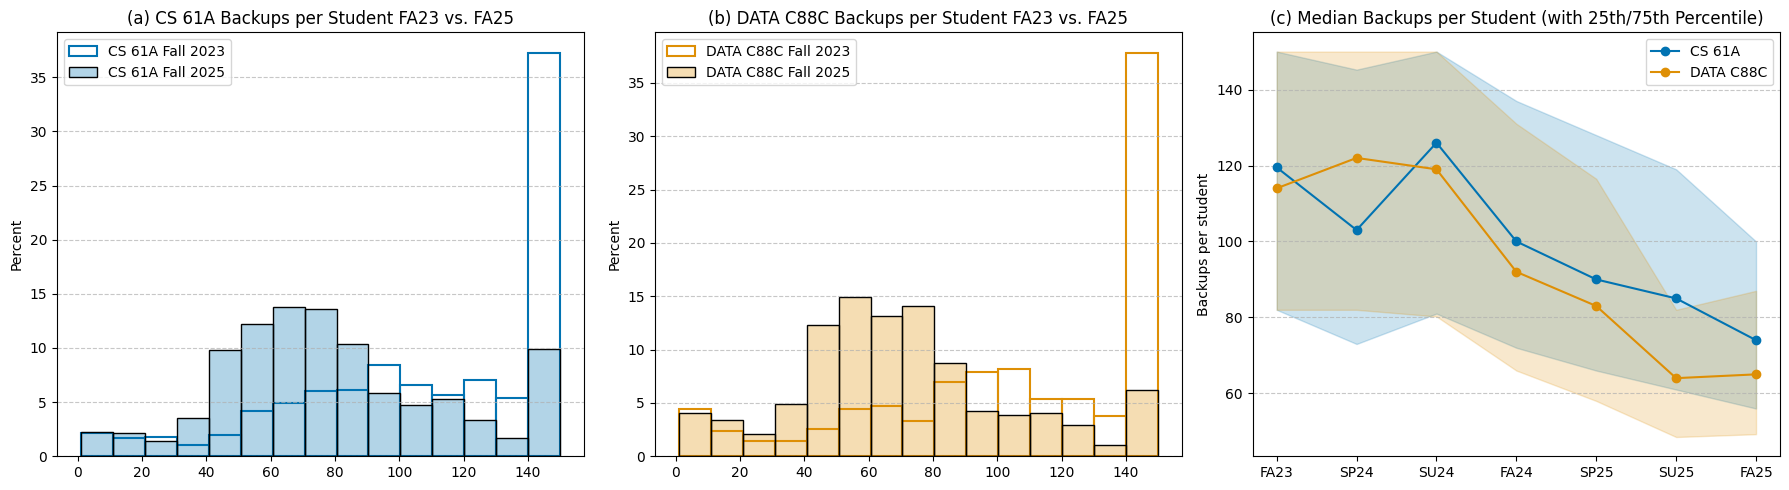

In [40]:
# Create the figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot (a): CS 61A Histogram ---
cs_61a = {
    key: val
    for key, val in results["backups_per_student"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL)) and key.cs61a
}

ax0 = axes[0]
for term_key, values in cs_61a.items():
    is_fa25 = term_key.year == 2025

    sns.histplot(
        x=values,
        ax=ax0,
        color=course_colors["CS 61A"],
        label=f"{term_key}",
        fill=is_fa25,  # fill = fa25, outline = fa23
        alpha=0.3 if is_fa25 else 1.0,
        stat="percent",
        common_norm=False,
        binwidth=10,
    )
ax0.set_title("(a) CS 61A Backups per Student FA23 vs. FA25")
ax0.grid(axis="y", linestyle="--", alpha=0.7)
ax0.legend()

# --- Plot (b): DATA C88C Histogram ---
data_88c = {
    key: val
    for key, val in results["backups_per_student"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
    and not key.cs61a
}

ax1 = axes[1]
for term_key, values in data_88c.items():
    is_fa25 = term_key.year == 2025

    sns.histplot(
        x=values,
        ax=ax1,
        color=course_colors["DATA C88C"],
        label=f"{term_key}",
        fill=is_fa25,
        alpha=0.3 if is_fa25 else 1.0,
        stat="percent",
        common_norm=False,
        binwidth=10,
    )
ax1.set_title("(b) DATA C88C Backups per Student FA23 vs. FA25")
ax1.grid(axis="y", linestyle="--", alpha=0.7)
ax1.legend()

# --- Plot (c): Median and IQR ---
bps_stats = {"Course": [], "Term": [], "Median": [], "p25": [], "p75": []}

for course in courses:
    data = results["backups_per_student"][course]
    bps_stats["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    bps_stats["Term"].append(course.term_string.upper())
    bps_stats["Median"].append(np.median(data))
    bps_stats["p25"].append(np.percentile(data, 25))
    bps_stats["p75"].append(np.percentile(data, 75))

# Plot medians and fill percentiles for each course
for course_name in ["CS 61A", "DATA C88C"]:
    # Filter data for this course
    c_data = {
        k: [
            bps_stats[k][i]
            for i, v in enumerate(bps_stats["Course"])
            if v == course_name
        ]
        for k in bps_stats
    }

    # Plot the median line
    axes[2].plot(
        c_data["Term"],
        c_data["Median"],
        marker="o",
        label=course_name,
        color=course_colors[course_name],
    )

    # Plot the IQR as a shaded area
    axes[2].fill_between(
        c_data["Term"],
        c_data["p25"],
        c_data["p75"],
        color=course_colors[course_name],
        alpha=0.2,
    )

axes[2].set_title("(c) Median Backups per Student (with 25th/75th Percentile)")
axes[2].set_ylabel("Backups per student")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.show()

## Total time spent

In [14]:
def total_time_spent(cursor: sqlite3.Cursor) -> np.array:
    cursor.execute("""
        SELECT julianday(MAX(created)) - julianday(MIN(created)) AS total_time_spent_days
        FROM backup_metadata
        GROUP BY student_email
    """)
    return np.array([row[0] for row in cursor.fetchall()])

In [15]:
results["total_time_spent_days"] = {}

for course, cur in zip(courses, cursors):
    results["total_time_spent_days"][course] = total_time_spent(cur)

<Axes: ylabel='Count'>

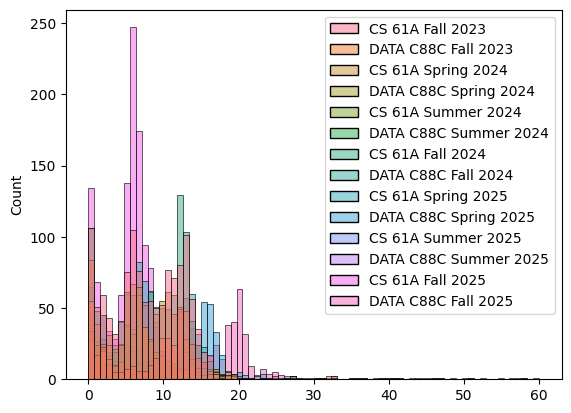

In [16]:
sns.histplot(data=results["total_time_spent_days"], binrange=(0, 60))

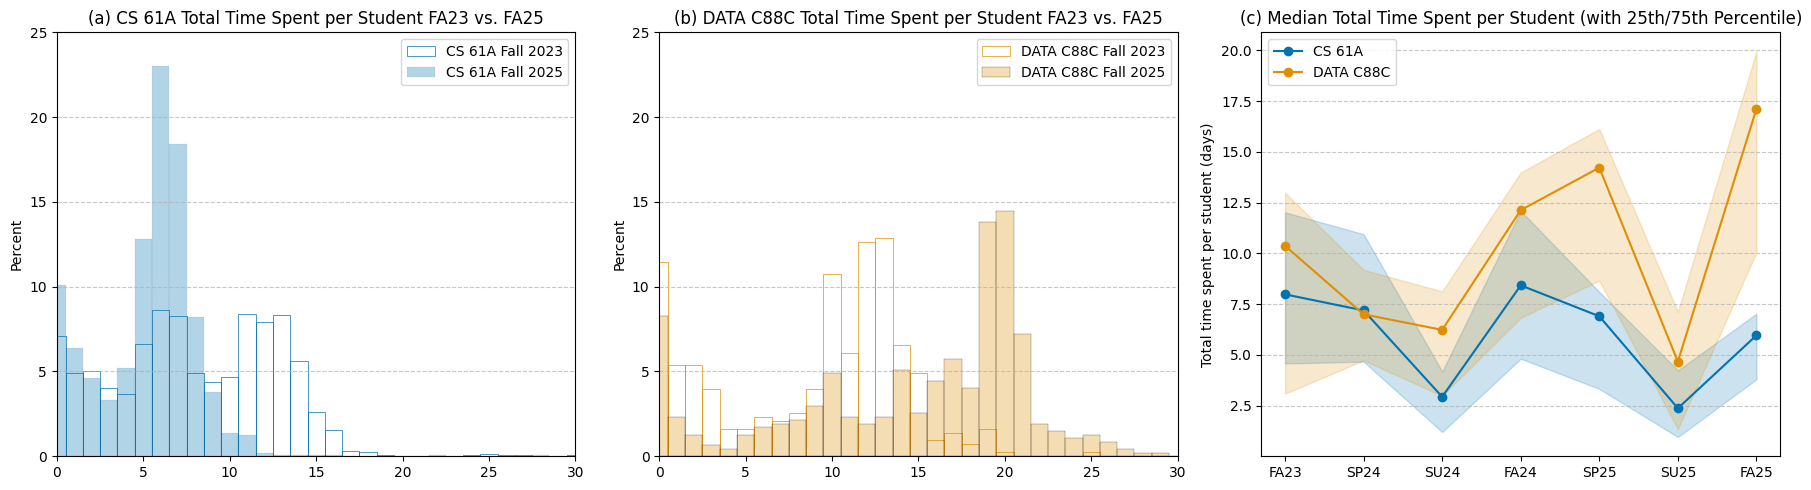

In [41]:
# Create the figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot (a): CS 61A Histogram ---
cs_61a = {
    key: val
    for key, val in results["total_time_spent_days"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL)) and key.cs61a
}

ax0 = axes[0]
for term_key, values in cs_61a.items():
    is_fa25 = term_key.year == 2025

    sns.histplot(
        x=values,
        ax=ax0,
        color=course_colors["CS 61A"],
        label=f"{term_key}",
        fill=is_fa25,
        alpha=0.3 if is_fa25 else 1.0,
        stat="percent",
        common_norm=False,
        binwidth=5,
        discrete=True,
    )
ax0.set_xlim((0, 30))
ax0.set_ylim((0, 25))
ax0.set_title("(a) CS 61A Total Time Spent per Student FA23 vs. FA25")
ax0.grid(axis="y", linestyle="--", alpha=0.7)
ax0.legend()

# --- Plot (b): DATA C88C Histogram ---
data_88c = {
    key: val
    for key, val in results["total_time_spent_days"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
    and not key.cs61a
}

ax1 = axes[1]
for term_key, values in data_88c.items():
    is_fa25 = term_key.year == 2025

    sns.histplot(
        x=values,
        ax=ax1,
        color=course_colors["DATA C88C"],
        label=f"{term_key}",
        fill=is_fa25,
        alpha=0.3 if is_fa25 else 1.0,
        stat="percent",
        common_norm=False,
        binwidth=5,
        discrete=True,
    )
ax1.set_xlim((0, 30))
ax1.set_ylim((0, 25))
ax1.grid(axis="y", linestyle="--", alpha=0.7)
ax1.set_title("(b) DATA C88C Total Time Spent per Student FA23 vs. FA25")
ax1.legend()

# --- Plot (c): Median and IQR ---
tts_stats = {"Course": [], "Term": [], "Median": [], "p25": [], "p75": []}

for course in courses:
    data = results["total_time_spent_days"][course]
    tts_stats["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    tts_stats["Term"].append(course.term_string.upper())
    tts_stats["Median"].append(np.median(data))
    tts_stats["p25"].append(np.percentile(data, 25))
    tts_stats["p75"].append(np.percentile(data, 75))

# Plot medians and fill percentiles for each course
for course_name in ["CS 61A", "DATA C88C"]:
    # Filter data for this course
    c_data = {
        k: [
            tts_stats[k][i]
            for i, v in enumerate(tts_stats["Course"])
            if v == course_name
        ]
        for k in tts_stats
    }

    # Plot the median line
    axes[2].plot(
        c_data["Term"],
        c_data["Median"],
        marker="o",
        label=course_name,
        color=course_colors[course_name],
    )

    # Plot the IQR as a shaded area
    axes[2].fill_between(
        c_data["Term"],
        c_data["p25"],
        c_data["p75"],
        color=course_colors[course_name],
        alpha=0.2,
    )

axes[2].set_title("(c) Median Total Time Spent per Student (with 25th/75th Percentile)")
axes[2].set_ylabel("Total time spent per student (days)")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.show()

## Project completion

In [18]:
def problems_solved_by_last_backup(cursor: sqlite3.Cursor) -> np.array:
    def count_problems_solved(history: list[dict]) -> int:
        solved = 0
        for problem in history:
            if problem["solved"]:
                solved += 1
        return solved

    cursor.execute("""
    WITH last_backups AS (
        SELECT
            student_email,
            backup_id,
            MAX(created) AS last_created
        FROM backup_metadata
        GROUP BY student_email
    )

    SELECT
        lb.*,
        history
    FROM analytics_messages AS am
    JOIN last_backups AS lb
    ON am.backup_id = lb.backup_id
    """)
    # list of lists, where inner list contains JSON objects representing problem solve state
    # 1 inner list per student
    last_backup_analytics_histories = [json.loads(row[3]) for row in cursor.fetchall()]

    # flatten using count_problems_solved
    # returns 1D list of len(students)
    return np.array(list(map(count_problems_solved, last_backup_analytics_histories)))

In [19]:
results["problems_solved_by_last_backup"] = {}

for course, cur in zip(courses, cursors):
    results["problems_solved_by_last_backup"][course] = problems_solved_by_last_backup(
        cur
    )

<Axes: ylabel='Percent'>

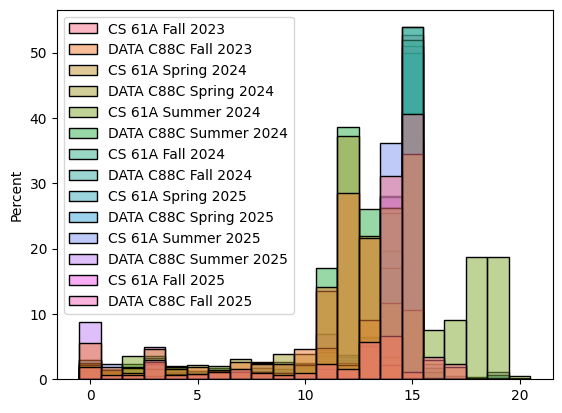

In [20]:
sns.histplot(
    data=results["problems_solved_by_last_backup"],
    stat="percent",
    common_norm=False,
    binrange=(0, 20),
    discrete=True,
)

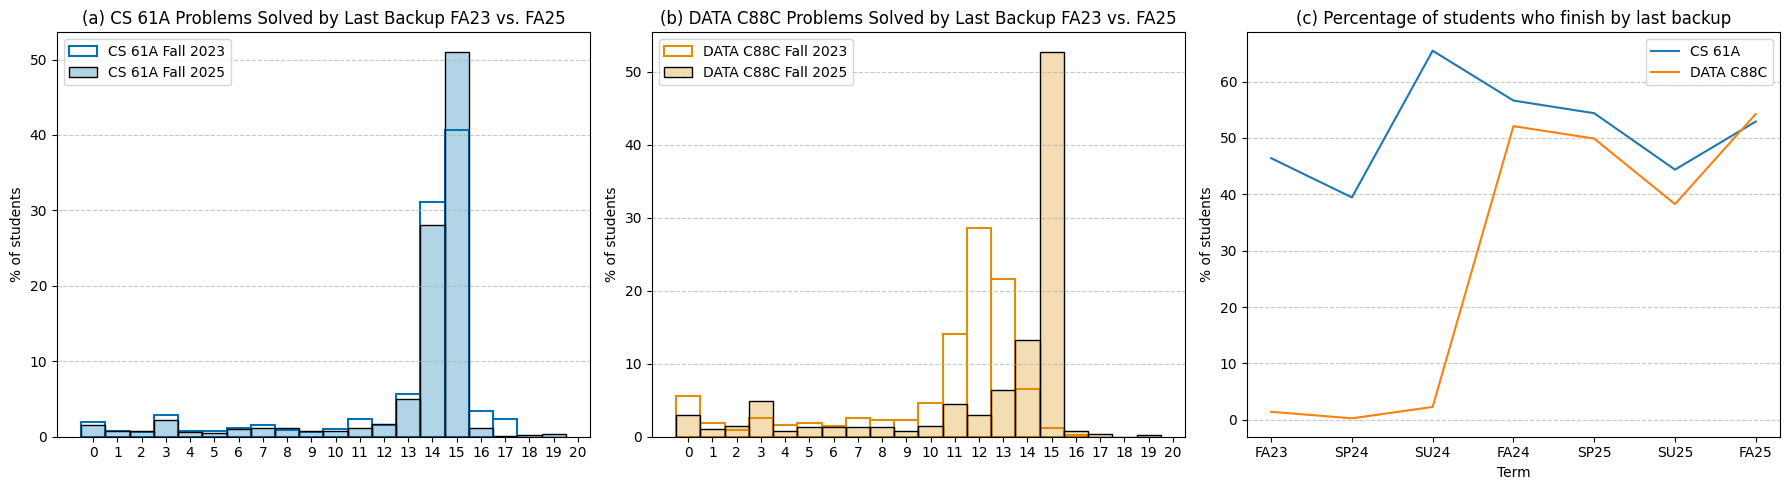

In [42]:
# Create the figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot (a): CS 61A Histogram ---
cs_61a = {
    key: val
    for key, val in results["problems_solved_by_last_backup"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL)) and key.cs61a
}

ax0 = axes[0]
for term_key, values in cs_61a.items():
    is_fa25 = term_key.year == 2025

    sns.histplot(
        x=values,
        ax=ax0,
        color=course_colors["CS 61A"],
        label=f"{term_key}",
        fill=is_fa25,
        alpha=0.3 if is_fa25 else 1.0,
        stat="percent",
        common_norm=False,
        discrete=True,
    )
ax0.set_xticks(range(0, 21))
ax0.set_ylabel("% of students")
ax0.set_title("(a) CS 61A Problems Solved by Last Backup FA23 vs. FA25")
ax0.grid(axis="y", linestyle="--", alpha=0.7)
ax0.legend()

# --- Plot (b): DATA C88C Histogram ---
data_88c = {
    key: val
    for key, val in results["problems_solved_by_last_backup"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
    and not key.cs61a
}

ax1 = axes[1]
for term_key, values in data_88c.items():
    is_fa25 = term_key.year == 2025

    sns.histplot(
        x=values,
        ax=ax1,
        color=course_colors["DATA C88C"],
        label=f"{term_key}",
        fill=is_fa25,
        alpha=0.3 if is_fa25 else 1.0,
        stat="percent",
        common_norm=False,
        discrete=True,
    )
ax1.set_xticks(range(0, 21))
ax1.set_ylabel("% of students")
ax1.set_title("(b) DATA C88C Problems Solved by Last Backup FA23 vs. FA25")
ax1.grid(axis="y", linestyle="--", alpha=0.7)
ax1.legend()

# --- Plot (c): Percentage of students over time ---
percent_students_finish = {
    "Course": [],
    "Term": [],
    "% of students who finish by last backup": [],
}

for course, cur in zip(courses, cursors):
    percent_students_finish["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    percent_students_finish["Term"].append(course.term_string.upper())

    num_students_finish = np.sum(
        results["problems_solved_by_last_backup"][course] >= 15
    )
    total_students = len(results["problems_solved_by_last_backup"][course])
    percent = (num_students_finish / total_students) * 100
    percent_students_finish["% of students who finish by last backup"].append(percent)

sns.lineplot(
    ax=axes[2],
    data=percent_students_finish,
    x="Term",
    y="% of students who finish by last backup",
    hue="Course",
)
axes[2].set_ylabel("% of students")
axes[2].set_title("(c) Percentage of students who finish by last backup")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.show()

## Problem(s) solved per day

In [22]:
def problems_per_day(cursor: sqlite3.Cursor) -> np.array:
    """
    This function duplicates some behavior from the `total_time_spent` and `problems_solved_by_last_backup`
    so that we match up student emails, otherwise it will error because the dimensions of the arrays don't match.
    Also this function filters out rows where the total_time_spent_days == 0
    """

    def count_problems_solved(history: list[dict]) -> int:
        solved = 0
        for problem in history:
            if problem["solved"]:
                solved += 1
        return solved

    cursor.execute("""
    WITH total_time_spent AS (
        SELECT
            student_email,
            julianday(MAX(created)) - julianday(MIN(created)) AS total_time_spent_days
        FROM backup_metadata
        GROUP BY student_email
    ),
    last_backups AS (
        SELECT
            student_email,
            backup_id,
            MAX(created) AS last_created
        FROM backup_metadata
        GROUP BY student_email
    ),
    joined AS (
        SELECT
            total_time_spent.student_email,
            total_time_spent.total_time_spent_days,
            last_backups.backup_id
        FROM total_time_spent
        JOIN last_backups ON total_time_spent.student_email = last_backups.student_email
    )
    SELECT
        j.*,
        am.history
    FROM analytics_messages AS am
    JOIN joined AS j
    ON am.backup_id = j.backup_id
    """)
    rows = cursor.fetchall()

    total_time_spent_days = [row[1] for row in rows if row[1] != 0]

    # list of lists, where inner list contains JSON objects representing problem solve state
    # 1 inner list per student
    last_backup_analytics_histories = [
        json.loads(row[3]) for row in rows if row[1] != 0
    ]

    # flatten using count_problems_solved
    # returns 1D list of len(students)
    problems_solved_by_last_backup = np.array(
        list(map(count_problems_solved, last_backup_analytics_histories))
    )

    return problems_solved_by_last_backup / total_time_spent_days

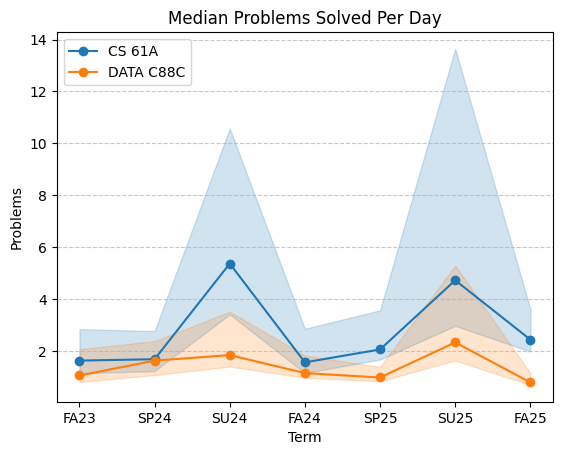

In [23]:
ppd_dict = {
    "Course": [],
    "Term": [],
    "Median problems solved per day": [],
    "p25": [],
    "p75": [],
}

for course, cur in zip(courses, cursors):
    ppd_dict["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    ppd_dict["Term"].append(course.term_string.upper())

    ppd = problems_per_day(cur)

    ppd_dict["Median problems solved per day"].append(np.median(ppd))
    ppd_dict["p25"].append(np.percentile(ppd, 25))
    ppd_dict["p75"].append(np.percentile(ppd, 75))

df = pd.DataFrame(ppd_dict)

for course_name in df["Course"].unique():
    course_df = df[df["Course"] == course_name]

    # Plot median line
    (line,) = plt.plot(
        course_df["Term"],
        course_df["Median problems solved per day"],
        marker="o",
        label=f"{course_name}",
    )

    # Plot IQR
    plt.fill_between(
        course_df["Term"],
        course_df["p25"],
        course_df["p75"],
        color=line.get_color(),
        alpha=0.2,
    )

plt.title("Median Problems Solved Per Day")
plt.xlabel("Term")
plt.ylabel("Problems")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Autograder spam

In [27]:
AG_SPAM_QUERY = """
WITH raw_time AS (
    -- Convert ISO8601 strings to unix timestamps for math
    SELECT
        student_email,
        strftime('%s', created) AS ts
    FROM backup_metadata
),
time_diffs AS (
    -- Get the timestamp of the previous backup for each student
    SELECT
        student_email,
        ts,
        LAG(ts) OVER (PARTITION BY student_email ORDER BY ts) AS prev_ts
    FROM raw_time
),
session_starts AS (
    -- Identify the start of a new session (gap > 900 seconds or 15 min)
    SELECT
        student_email,
        ts,
        CASE
            WHEN ts - prev_ts > 900 THEN 1
            ELSE 0
        END AS is_new_session
    FROM time_diffs
),
session_groups AS (
    -- Create a unique session_id by calculating a running sum of starts
    SELECT
        student_email,
        ts,
        SUM(is_new_session) OVER (PARTITION BY student_email ORDER BY ts) AS session_id
    FROM session_starts
),
worksession_stats AS (
    -- Aggregate by student and session_id
    SELECT
        student_email,
        COUNT(*) AS backup_count,
        (MAX(ts) - MIN(ts)) / 60.0 AS duration_minutes
    FROM session_groups
    GROUP BY student_email, session_id
),
-- Compute the all rates for all students (handling 0-minute sessions to avoid division by zero)
backups_per_minute_rates AS (
    SELECT
        student_email,
        CASE
            WHEN duration_minutes = 0 THEN 1.0  -- One backup is technically "1 per moment"
            ELSE backup_count / duration_minutes
        END AS backups_per_minute
    FROM worksession_stats
)
-- Average rates for each worksession for each student
SELECT
    student_email,
    AVG(backups_per_minute) AS backups_per_minute
FROM backups_per_minute_rates
GROUP BY student_email;
"""


def backups_per_minute(cursor: sqlite3.Cursor) -> np.array:
    cursor.execute(AG_SPAM_QUERY)
    return np.array([row["backups_per_minute"] for row in cursor.fetchall()])

In [28]:
results["backups_per_minute"] = {}

for course, cur in zip(courses, cursors):
    results["backups_per_minute"][course] = backups_per_minute(cur)

<Axes: ylabel='Count'>

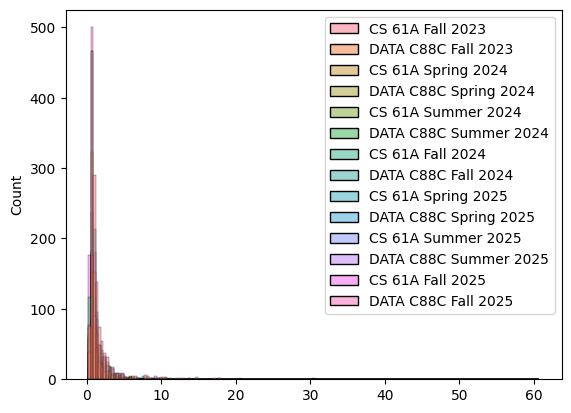

In [29]:
sns.histplot(data=results["backups_per_minute"])

<Axes: ylabel='Count'>

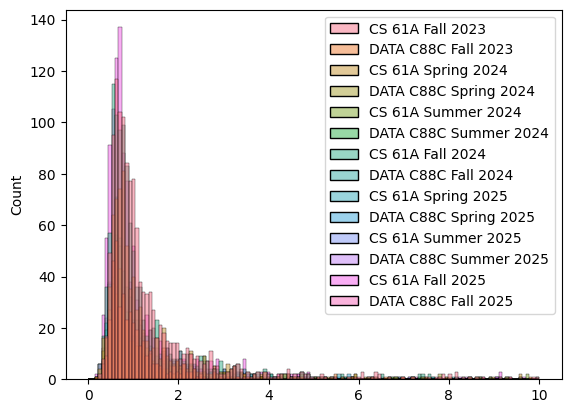

In [30]:
sns.histplot(data=results["backups_per_minute"], binrange=(0, 10))

<Axes: ylabel='Percent'>

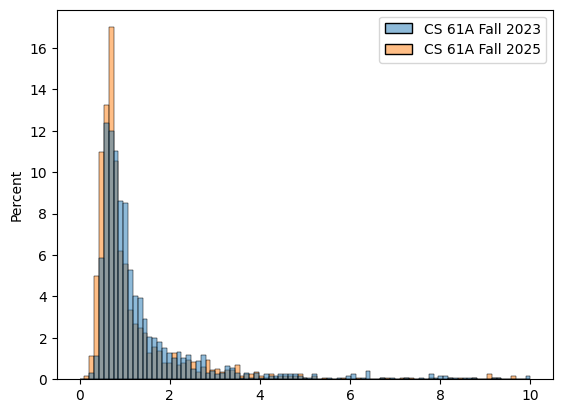

In [32]:
sns.histplot(
    data={
        key: val
        for key, val in results["backups_per_minute"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
    common_norm=False,
    binrange=(0, 10),
)

<Axes: ylabel='Percent'>

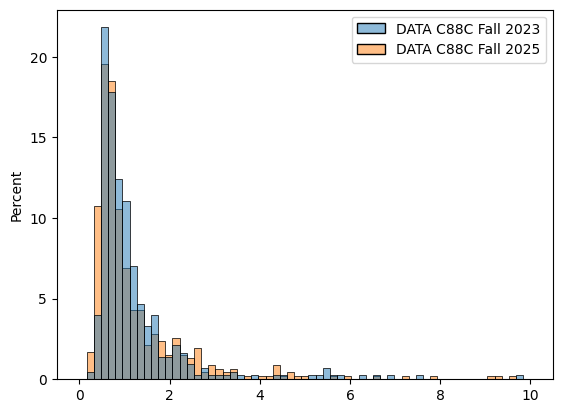

In [33]:
sns.histplot(
    data={
        key: val
        for key, val in results["backups_per_minute"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
    common_norm=False,
    binrange=(0, 10),
)

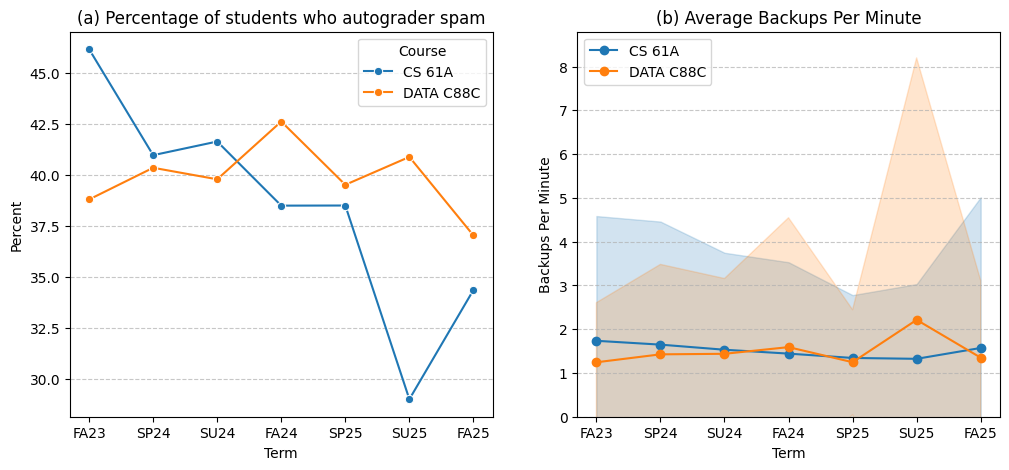

In [63]:
# Create the figure and axes (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1 (% of students who are autograder spamming) ---
# Compute values
percent_ag_spam = {
    "Course": [],
    "Term": [],
    # defined as > 1 backup/minute
    "% of students who autograder spam": [],
}

for course, cur in zip(courses, cursors):
    percent_ag_spam["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    percent_ag_spam["Term"].append(course.term_string.upper())

    num_students_spam = np.sum(results["backups_per_minute"][course] > 1)
    total_students = len(results["backups_per_minute"][course])
    percent = (num_students_spam / total_students) * 100
    percent_ag_spam["% of students who autograder spam"].append(percent)

# Plot
ax0 = axes[0]
sns.lineplot(
    data=percent_ag_spam,
    x="Term",
    y="% of students who autograder spam",
    hue="Course",
    marker="o",
    ax=ax0,
)
ax0.set_ylabel("Percent")
ax0.set_title("(a) Percentage of students who autograder spam")
ax0.grid(axis="y", linestyle="--", alpha=0.7)

# --- Plot 2 (Avg/std Backups per min) ---
# Compute values
backups_per_min_avg_std = {
    "Course": [],
    "Term": [],
    "avg_backups_per_min": [],
    "std_backups_per_min": [],
}

for course, cur in zip(courses, cursors):
    backups_per_min_avg_std["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    backups_per_min_avg_std["Term"].append(course.term_string.upper())

    backups_per_min_avg_std["avg_backups_per_min"].append(
        np.mean(results["backups_per_minute"][course])
    )
    backups_per_min_avg_std["std_backups_per_min"].append(
        np.std(results["backups_per_minute"][course])
    )

bpmas_df = pd.DataFrame.from_dict(backups_per_min_avg_std)

# Plot
ax1 = axes[1]
for course_name in bpmas_df["Course"].unique():
    course_df = bpmas_df[bpmas_df["Course"] == course_name]

    # Plot mean
    (line,) = ax1.plot(
        course_df["Term"],
        course_df["avg_backups_per_min"],
        marker="o",
        label=f"{course_name}",
    )

    # Plot +/- 1 STD
    under_line = course_df["avg_backups_per_min"] - course_df["std_backups_per_min"]
    over_line = course_df["avg_backups_per_min"] + course_df["std_backups_per_min"]
    ax1.fill_between(
        course_df["Term"],
        under_line,
        over_line,
        color=line.get_color(),
        alpha=0.2,
    )

ax1.set_title("(b) Average Backups Per Minute")
ax1.set_xlabel("Term")
ax1.set_ylabel("Backups Per Minute")
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.7)
# Cut off at y = 0 since negative backups per min doesn't make sense
ax1.set_ylim(bottom=0)

plt.show()

## Time between backups

In [64]:
TIME_BTWN_BACKUPS_QUERY = """
WITH raw_time AS (
    -- Convert ISO8601 strings to unix timestamps
    SELECT
        student_email,
        strftime('%s', created) AS ts
    FROM backup_metadata
),
time_diffs AS (
    -- Calculate the gap (in seconds) between current and previous backup
    SELECT
        student_email,
        ts,
        ts - LAG(ts) OVER (PARTITION BY student_email ORDER BY ts) AS gap_seconds
    FROM raw_time
),
session_groups AS (
    -- Identify session boundaries (gaps > 900s or 15 min)
    -- and use a running sum to group consecutive backups
    SELECT
        student_email,
        gap_seconds,
        SUM(CASE WHEN gap_seconds > 900 OR gap_seconds IS NULL THEN 1 ELSE 0 END)
            OVER (PARTITION BY student_email ORDER BY ts) AS session_id
    FROM time_diffs
)
-- Average the gaps that occur WITHIN sessions
-- (We filter out the first backup of every session because its gap is NULL or > 900)
SELECT
    student_email,
    AVG(gap_seconds) AS avg_duration_between_backups_seconds
FROM session_groups
WHERE gap_seconds <= 900
GROUP BY student_email;
"""


def time_between_backups(cursor: sqlite3.Cursor) -> np.array:
    cursor.execute(TIME_BTWN_BACKUPS_QUERY)
    return np.array(
        [row["avg_duration_between_backups_seconds"] for row in cursor.fetchall()]
    )

In [65]:
results["time_between_backups"] = {}

for course, cur in zip(courses, cursors):
    results["time_between_backups"][course] = time_between_backups(cur)

<Axes: ylabel='Count'>

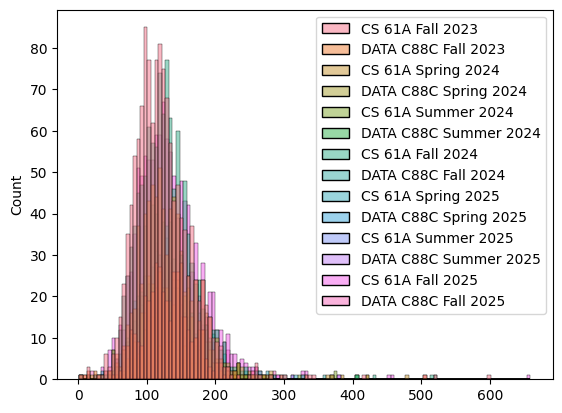

In [66]:
sns.histplot(data=results["time_between_backups"])

<Axes: ylabel='Percent'>

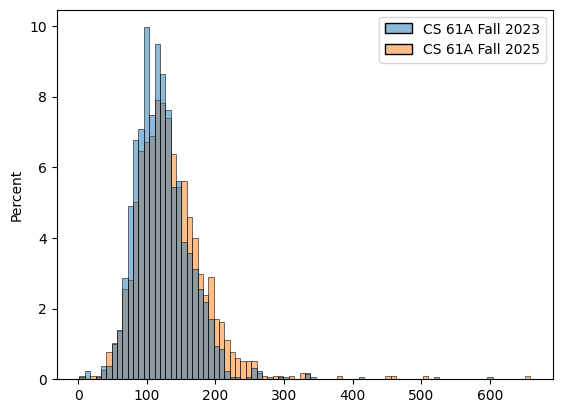

In [67]:
sns.histplot(
    data={
        key: val
        for key, val in results["time_between_backups"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
    common_norm=False,
)

<Axes: ylabel='Percent'>

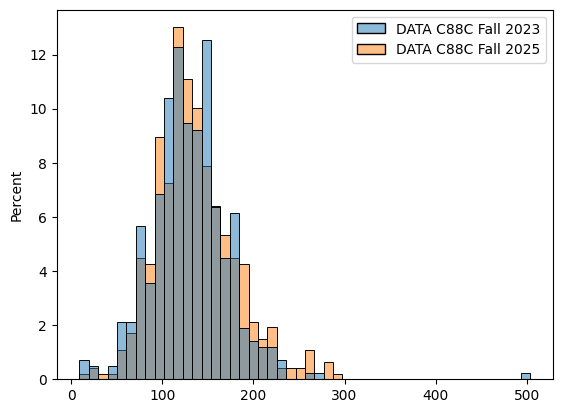

In [68]:
sns.histplot(
    data={
        key: val
        for key, val in results["time_between_backups"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
    common_norm=False,
)

In [72]:
median_time_btwn_backups = {
    "Course": [],
    "Term": [],
    "Median time between backups (sec)": [],
    "p25": [],
    "p75": [],
}

for course, cur in zip(courses, cursors):
    median_time_btwn_backups["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    median_time_btwn_backups["Term"].append(course.term_string.upper())
    median_time_btwn_backups["Median time between backups (sec)"].append(
        np.median(results["time_between_backups"][course])
    )
    median_time_btwn_backups["p25"].append(
        np.percentile(results["time_between_backups"][course], 25)
    )
    median_time_btwn_backups["p75"].append(
        np.percentile(results["time_between_backups"][course], 75)
    )

mtbb_df = pd.DataFrame.from_dict(median_time_btwn_backups)

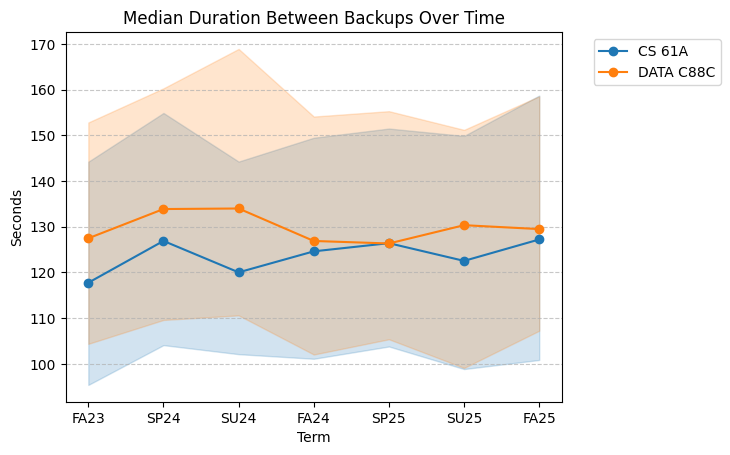

In [ ]:
for course_name in mtbb_df["Course"].unique():
    course_df = mtbb_df[mtbb_df["Course"] == course_name]

    # Plot median
    line, = plt.plot(
        course_df["Term"],
        course_df["Median time between backups (sec)"],
        marker='o',
        label=f"{course_name}"
    )

    # Plot IQR
    plt.fill_between(
        course_df["Term"],
        course_df["p25"],
        course_df["p75"],
        color=line.get_color(),
        alpha=0.2,
    )

plt.title("Median Duration Between Backups Over Time")
plt.xlabel("Term")
plt.ylabel("Seconds")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Number of lines

In [76]:
NET_NUM_LINES_QUERY = """
WITH backup_line_counts AS (
    SELECT
        m.student_email,
        m.course,
        m.assignment,
        m.created,
        f.file_name,
        f.num_lines
    FROM backup_metadata AS m
    JOIN backup_file_metadata AS f
    ON m.file_contents_location = f.file_contents_location
),

consecutive_changes AS (
    -- Step 2: Use LAG to find the line count of the previous backup
    SELECT
        student_email,
        course,
        assignment,
        created,
        file_name,
        num_lines AS current_lines,
        LAG(num_lines) OVER (
            PARTITION BY student_email, course, assignment, file_name
            ORDER BY created ASC
        ) AS prev_lines
    FROM backup_line_counts
),

-- each row is a student's backup with line diff count
line_diffs AS (
    SELECT
        student_email,
        course,
        assignment,
        file_name,
        created,
        current_lines,
        prev_lines,
        -- for first backup, there is no prev_lines
        (current_lines - IFNULL(prev_lines, current_lines)) AS lines_diff
    FROM consecutive_changes
    ORDER BY student_email, created ASC
)

SELECT
    student_email,
    AVG(lines_diff)
FROM line_diffs
GROUP BY student_email
ORDER BY AVG(lines_diff) DESC, student_email
"""


def net_num_lines_added(cursor: sqlite3.Cursor) -> np.array:
    cursor.execute(NET_NUM_LINES_QUERY)
    return [row[1] for row in cursor.fetchall()]

In [77]:
results["net_num_lines_added"] = {}

for course, cur in zip(courses, cursors):
    results["net_num_lines_added"][course] = net_num_lines_added(cur)

<Axes: ylabel='Count'>

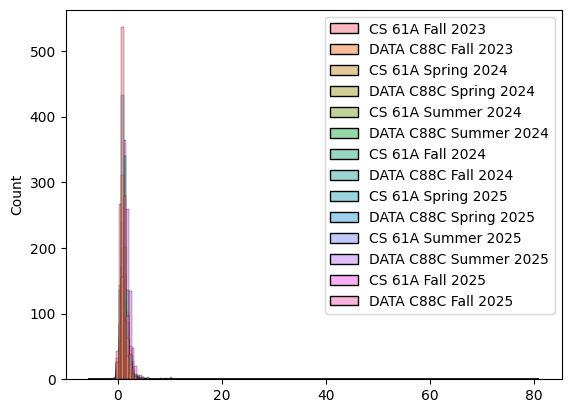

In [78]:
sns.histplot(data=results["net_num_lines_added"])

<Axes: ylabel='Count'>

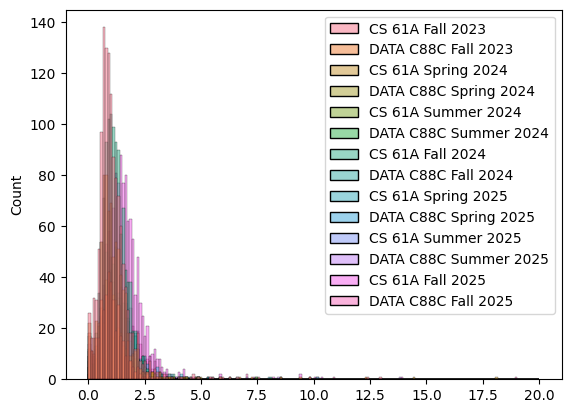

In [79]:
sns.histplot(data=results["net_num_lines_added"], binrange=(0, 20))

<Axes: ylabel='Percent'>

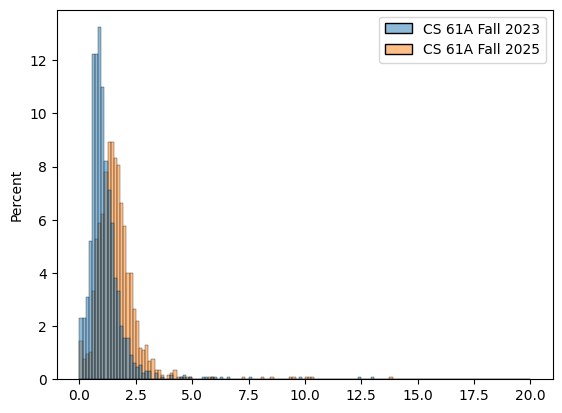

In [81]:
sns.histplot(
    data={
        key: val
        for key, val in results["net_num_lines_added"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
    stat="percent",
    common_norm=False,
    binrange=(0, 20),
)

<Axes: ylabel='Percent'>

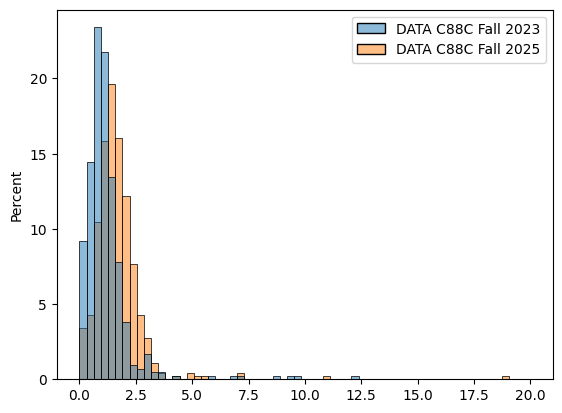

In [82]:
sns.histplot(
    data={
        key: val
        for key, val in results["net_num_lines_added"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
    stat="percent",
    common_norm=False,
    binrange=(0, 20),
)

In [83]:
median_net_num_lines_added = {
    "Course": [],
    "Term": [],
    "Median net number of lines added": [],
    "p25": [],
    "p75": [],
}

for course, cur in zip(courses, cursors):
    median_net_num_lines_added["Course"].append(
        "CS 61A" if course.cs61a else "DATA C88C"
    )
    median_net_num_lines_added["Term"].append(course.term_string.upper())
    median_net_num_lines_added["Median net number of lines added"].append(
        np.median(results["net_num_lines_added"][course])
    )
    median_net_num_lines_added["p25"].append(
        np.percentile(results["net_num_lines_added"][course], 25)
    )
    median_net_num_lines_added["p75"].append(
        np.percentile(results["net_num_lines_added"][course], 75)
    )

mnnla_df = pd.DataFrame.from_dict(median_net_num_lines_added)

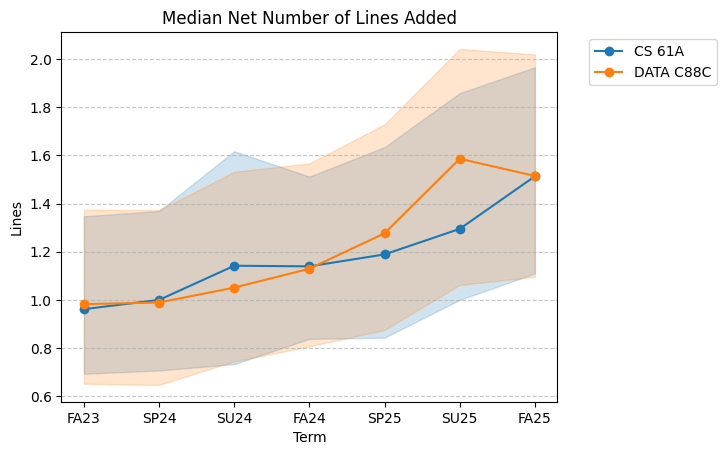

In [ ]:
for course_name in mnnla_df["Course"].unique():
    course_df = mnnla_df[mnnla_df["Course"] == course_name]

    # Plot median
    line, = plt.plot(
        course_df["Term"],
        course_df["Median net number of lines added"],
        marker='o',
        label=f"{course_name}"
    )

    # Plot IQR
    plt.fill_between(
        course_df["Term"],
        course_df["p25"],
        course_df["p75"],
        color=line.get_color(),
        alpha=0.2,
    )

plt.title("Median Net Number of Lines Added")
plt.xlabel("Term")
plt.ylabel("Lines")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Print debugging

In [86]:
# Only count user-generated print statements; these were in the skeleton code
IGNORE_LINES = [
    "print('All bees are vanquished. You win!')",
    "print('The bees reached homebase or the queen ant queen has perished. Please try again :(')",
    "print(message)",
]

# Regex for Python print statements: matches lines starting with print(...)
# ^\s* matches optional leading whitespace
PRINT_REGEX = re.compile(r"^\s*print\s*\(.*\)")


def count_print_statements(file_path):
    count = 0
    try:
        with open(file_path) as f:
            for line in f:
                clean_line = line.strip()
                if PRINT_REGEX.match(line) and clean_line not in IGNORE_LINES:
                    count += 1
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return 0
    return count

In [87]:
def num_occurrences_print(cursor: sqlite3.Cursor) -> dict[str, list]:
    cursor.execute("""
        SELECT backup_id, student_email, created, file_contents_location || '/ants.py' AS file_contents_location
        FROM backup_metadata
    """)
    query_results = cursor.fetchall()

    print_debug_data = {
        # TODO find out why there is a path that is None
        "backup_id": [row[0] for row in query_results if row[3]],
        "student_email": [row[1] for row in query_results if row[3]],
        "created": [row[2] for row in query_results if row[3]],
        "num_occurrences_print": [],
    }

    file_paths = [row[3] for row in query_results]
    for path in tqdm(file_paths, unit="file"):
        if path:
            print_debug_data["num_occurrences_print"].append(
                count_print_statements(path)
            )
    return print_debug_data

In [88]:
results["num_occurrences_print"] = {}

for course, cur in zip(courses, cursors):
    results["num_occurrences_print"][course] = num_occurrences_print(cur)

100%|██████████| 33323/33323 [00:08<00:00, 3884.56file/s]


In [89]:
def backups_with_print(print_debug_data: dict[str, list]) -> np.array:
    df = pd.DataFrame(print_debug_data)
    df["has_print"] = df["num_occurrences_print"] >= 1
    student_aggregation = df.groupby("student_email")["has_print"].sum().reset_index()
    student_aggregation.columns = ["student_email", "backups_with_prints"]
    return np.array(student_aggregation["backups_with_prints"])

In [90]:
results["backups_with_print"] = {}

for course, cur in zip(courses, cursors):
    results["backups_with_print"][course] = backups_with_print(
        results["num_occurrences_print"][course]
    )

<Axes: ylabel='Count'>

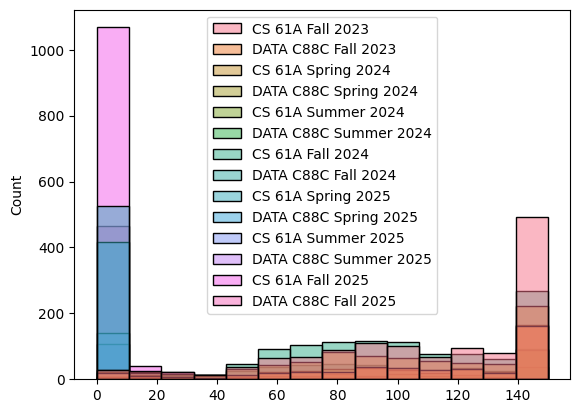

In [91]:
sns.histplot(data=results["backups_with_print"])

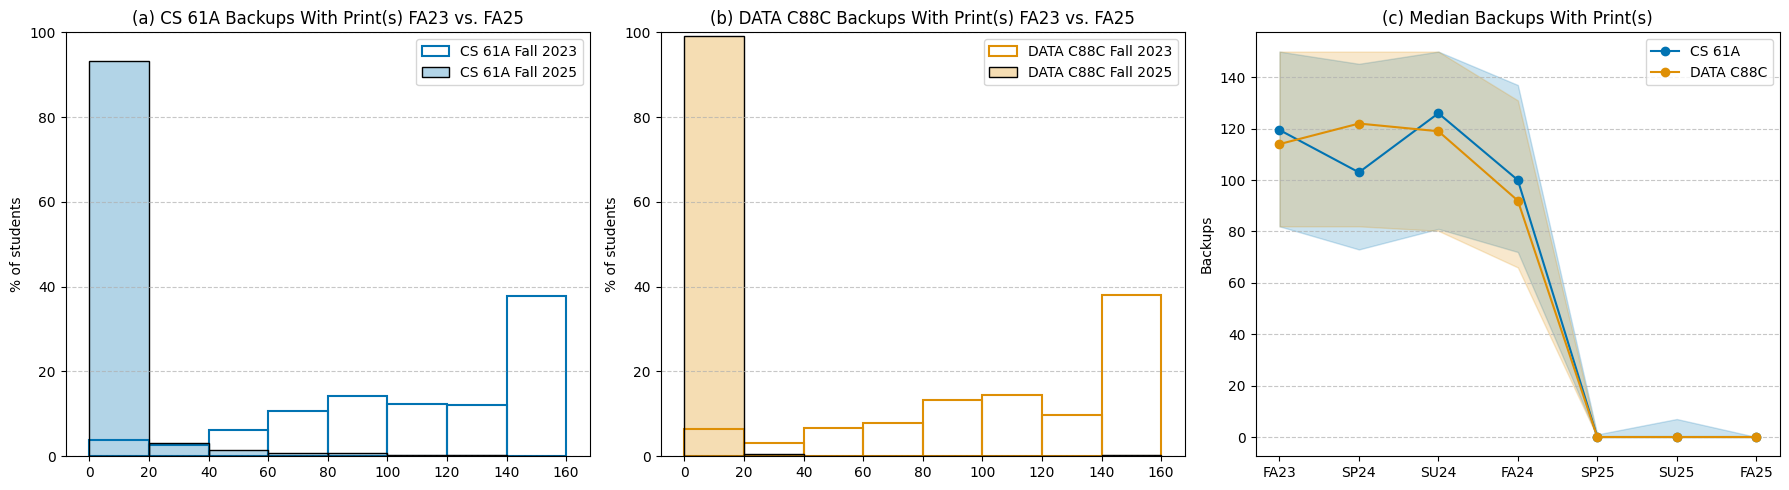

In [108]:
# Create the figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot (a): CS 61A Histogram ---
cs_61a = {
    key: val
    for key, val in results["backups_with_print"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL)) and key.cs61a
}

ax0 = axes[0]
for term_key, values in cs_61a.items():
    is_fa25 = term_key.year == 2025

    sns.histplot(
        x=values,
        ax=ax0,
        color=course_colors["CS 61A"],
        label=f"{term_key}",
        fill=is_fa25,
        alpha=0.3 if is_fa25 else 1.0,
        stat="percent",
        common_norm=False,
        binwidth=20,
        binrange=(0, 160),
    )
ax0.set_ylim((0, 100))
ax0.set_title("(a) CS 61A Backups With Print(s) FA23 vs. FA25")
ax0.set_ylabel("% of students")
ax0.grid(axis="y", linestyle="--", alpha=0.7)
ax0.legend()

# --- Plot (b): DATA C88C Histogram ---
data_88c = {
    key: val
    for key, val in results["backups_with_print"].items()
    if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
    and not key.cs61a
}

ax1 = axes[1]
for term_key, values in data_88c.items():
    is_fa25 = term_key.year == 2025

    sns.histplot(
        x=values,
        ax=ax1,
        color=course_colors["DATA C88C"],
        label=f"{term_key}",
        fill=is_fa25,
        alpha=0.3 if is_fa25 else 1.0,
        stat="percent",
        common_norm=False,
        binwidth=20,
        binrange=(0, 160),
    )
ax1.grid(axis="y", linestyle="--", alpha=0.7)
ax1.set_title("(b) DATA C88C Backups With Print(s) FA23 vs. FA25")
ax1.set_ylabel("% of students")
ax1.set_ylim((0, 100))
ax1.legend()

# --- Plot (c): Median and IQR ---
tts_stats = {"Course": [], "Term": [], "Median": [], "p25": [], "p75": []}

for course in courses:
    data = results["backups_with_print"][course]
    tts_stats["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    tts_stats["Term"].append(course.term_string.upper())
    tts_stats["Median"].append(np.median(data))
    tts_stats["p25"].append(np.percentile(data, 25))
    tts_stats["p75"].append(np.percentile(data, 75))

# Plot medians and fill percentiles for each course
for course_name in ["CS 61A", "DATA C88C"]:
    # Filter data for this course
    c_data = {
        k: [
            tts_stats[k][i]
            for i, v in enumerate(tts_stats["Course"])
            if v == course_name
        ]
        for k in tts_stats
    }

    # Plot the median line
    axes[2].plot(
        c_data["Term"],
        c_data["Median"],
        marker="o",
        label=course_name,
        color=course_colors[course_name],
    )

    # Plot the IQR as a shaded area
    axes[2].fill_between(
        c_data["Term"],
        c_data["p25"],
        c_data["p75"],
        color=course_colors[course_name],
        alpha=0.2,
    )

axes[2].set_title("(c) Median Backups With Print(s)")
axes[2].set_ylabel("Backups")
axes[2].grid(axis="y", linestyle="--", alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.show()

## Lint Errors

## Total number of lint errors across all backups

In [182]:
IGNORED_MESSAGES = [
    "`ucb.interact` imported but unused",
    "`ucb.main` imported but unused",
    "`ucb.trace` imported but unused",
]


def total_lint_errors_all_backups(cursor: sqlite3.Cursor) -> int:
    # Create a string of placeholders: (?, ?, ?)
    placeholders = ", ".join(["?"] * len(IGNORED_MESSAGES))

    query = f"""
        SELECT COUNT(*)
        FROM lint_errors
        WHERE message NOT IN ({placeholders})
        """

    cursor.execute(query, IGNORED_MESSAGES)
    return cursor.fetchone()[0]

In [183]:
results["total_lint_errors_all_backups"] = {}

for course, cur in zip(courses, cursors):
    results["total_lint_errors_all_backups"][course] = total_lint_errors_all_backups(
        cur
    )

In [187]:
tleab = {
    "Course": [],
    "Term": [],
    "Total lint errors (all backups and students)": [],
}

for course, cur in zip(courses, cursors):
    tleab["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    tleab["Term"].append(course.term_string.upper())
    tleab["Total lint errors (all backups and students)"].append(
        results["total_lint_errors_all_backups"][course]
    )

tleab = pd.DataFrame.from_dict(tleab)

<Axes: xlabel='Term', ylabel='Total lint errors (all backups and students)'>

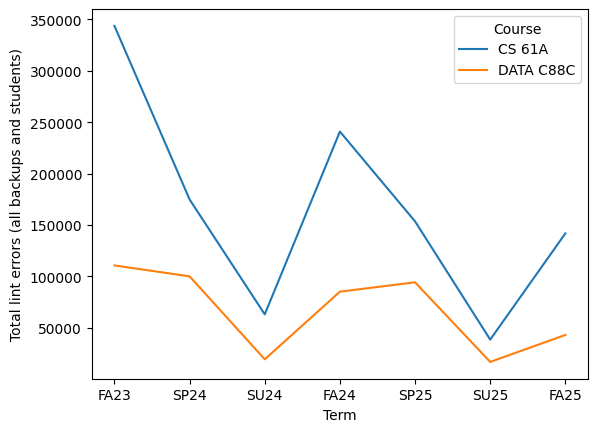

In [188]:
sns.lineplot(
    data=tleab, x="Term", y="Total lint errors (all backups and students)", hue="Course"
)

## Top error codes across all backups

In [9]:
IGNORED_MESSAGES = [
    "`ucb.interact` imported but unused",
    "`ucb.main` imported but unused",
    "`ucb.trace` imported but unused",
]


def lint_error_freqs_all_backups(cursor: sqlite3.Cursor) -> pd.DataFrame:
    # Create a string of placeholders: (?, ?, ?)
    placeholders = ", ".join(["?"] * len(IGNORED_MESSAGES))

    query = f"""
        SELECT code, COUNT(*) AS frequency, url
        FROM lint_errors
        WHERE message NOT IN ({placeholders})
        GROUP BY code
        ORDER BY COUNT(*) DESC
        """

    cursor.execute(query, IGNORED_MESSAGES)

    columns = [column[0] for column in cursor.description]
    return pd.DataFrame(cursor.fetchall(), columns=columns)

In [176]:
results["lint_error_freqs_all_backups"] = {}

for course, cur in zip(courses, cursors):
    results["lint_error_freqs_all_backups"][course] = lint_error_freqs_all_backups(cur)

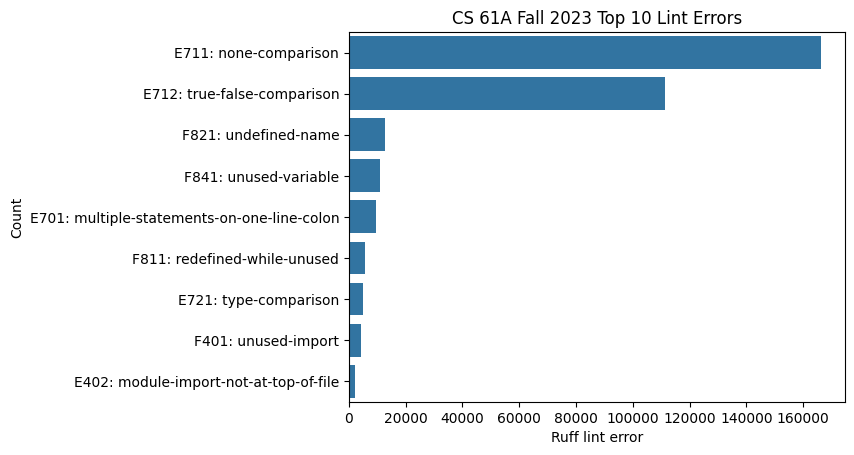

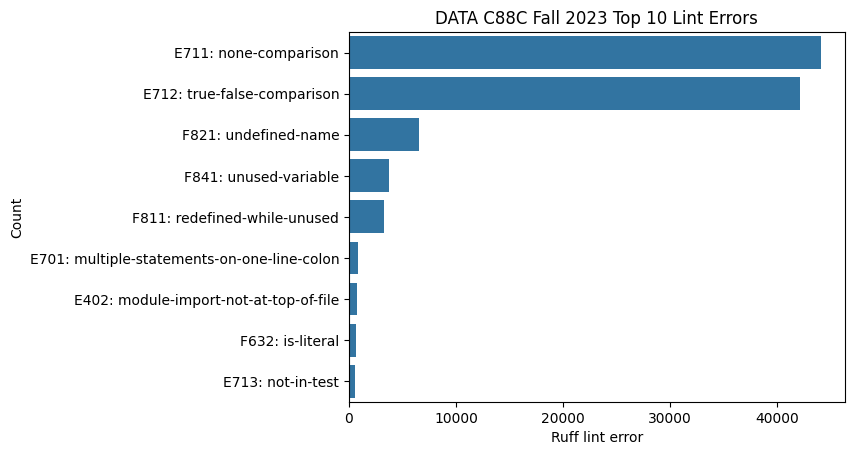

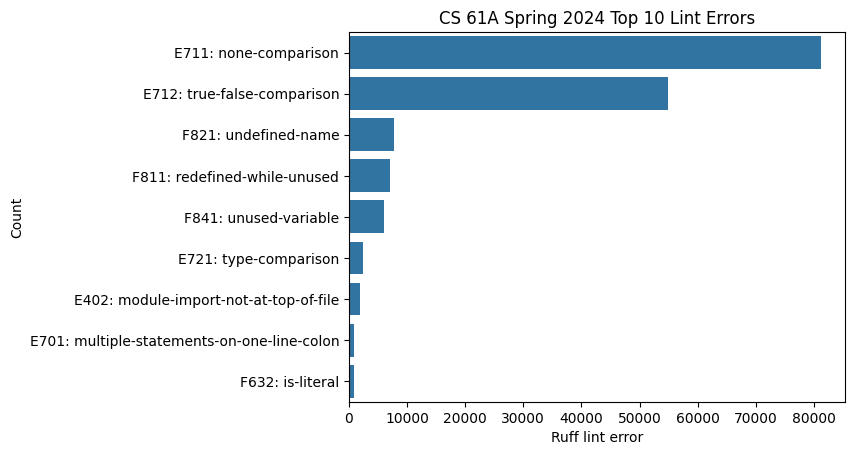

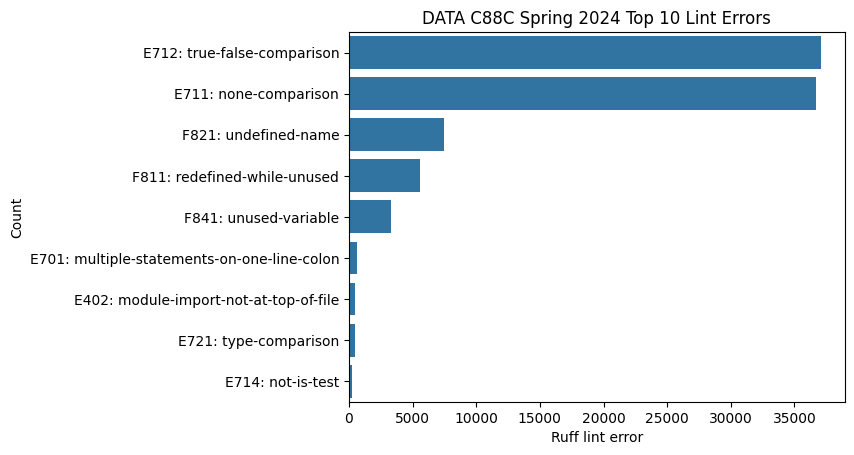

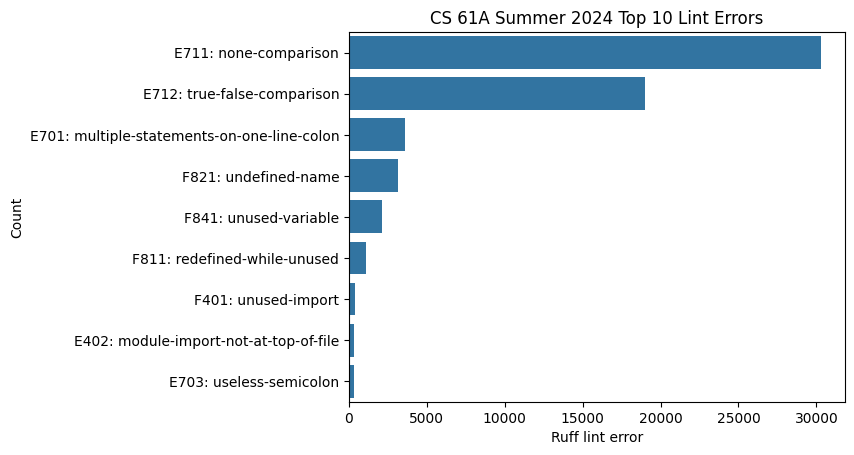

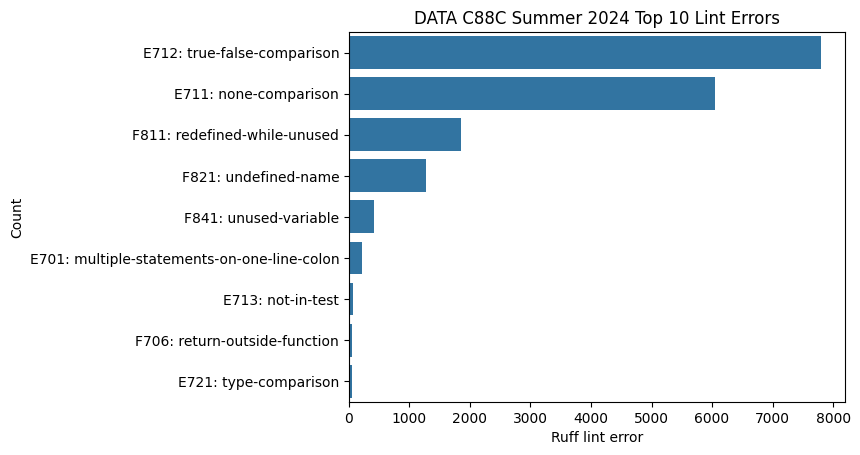

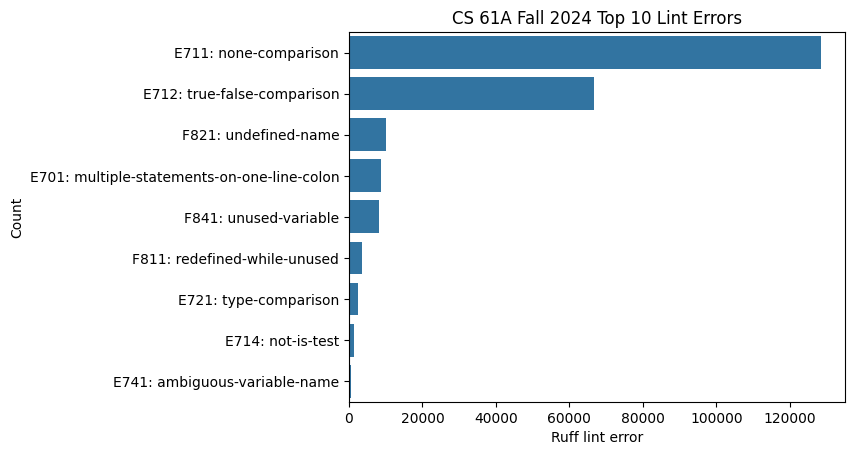

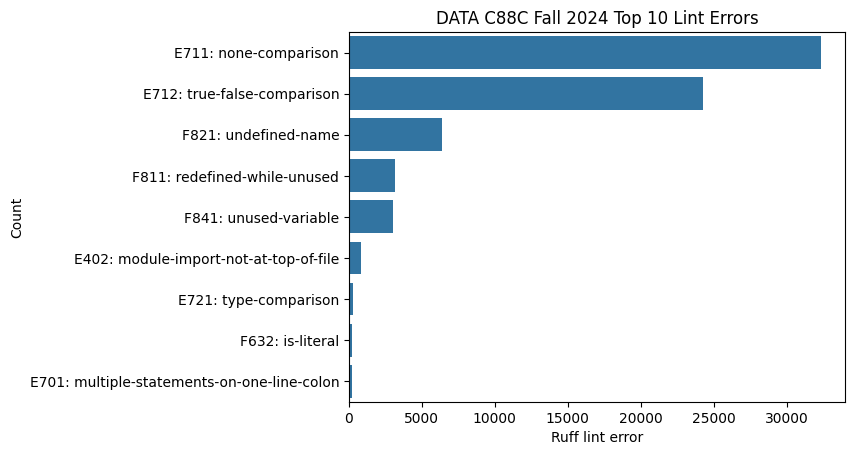

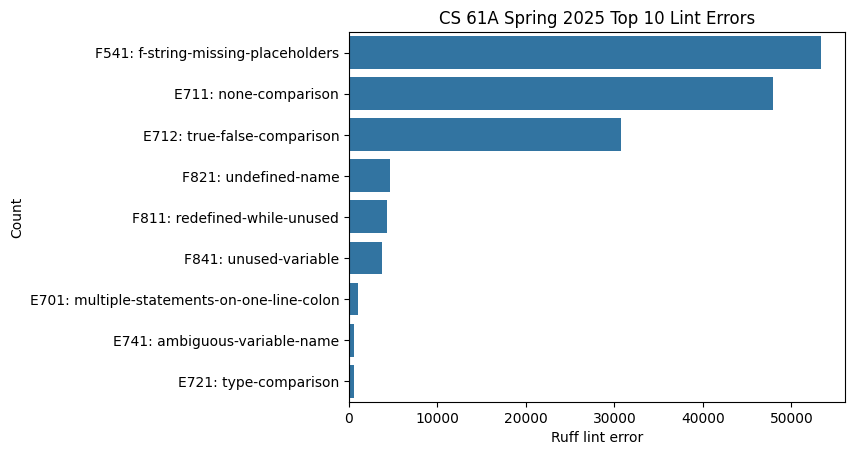

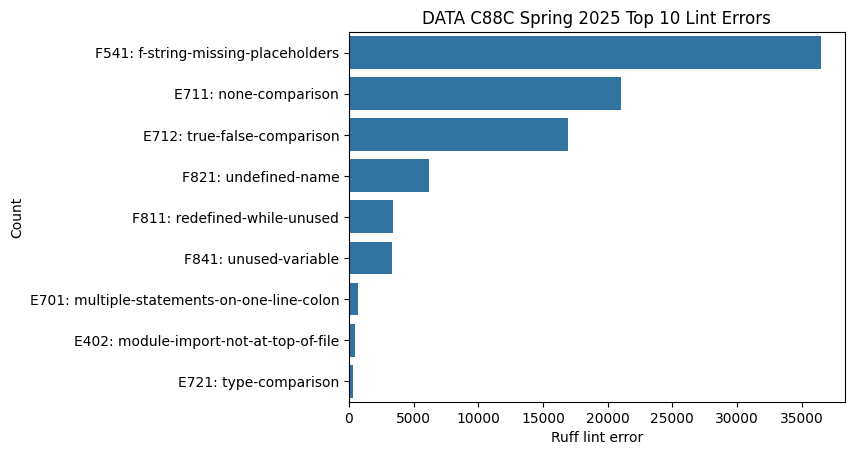

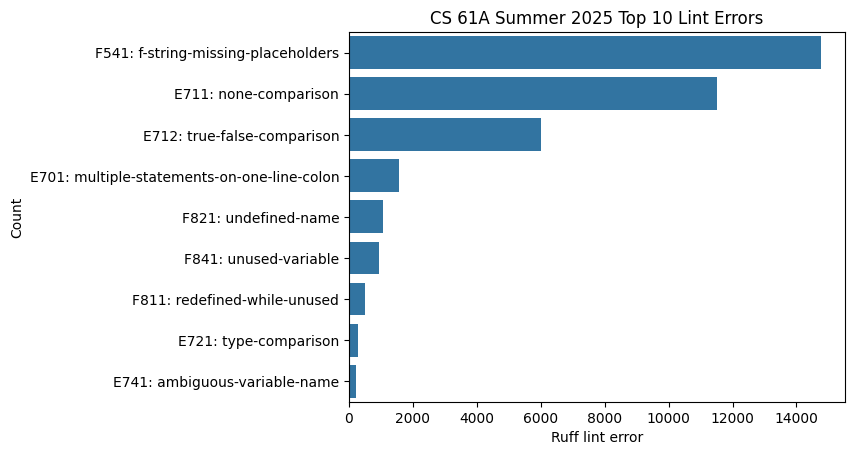

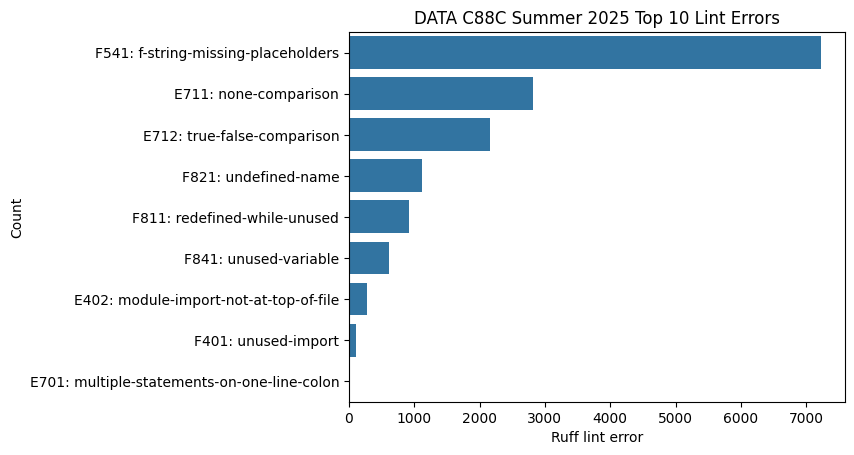

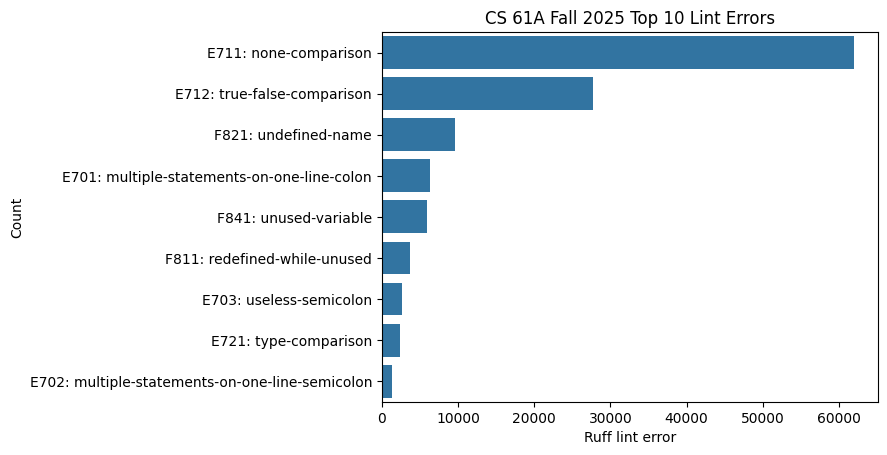

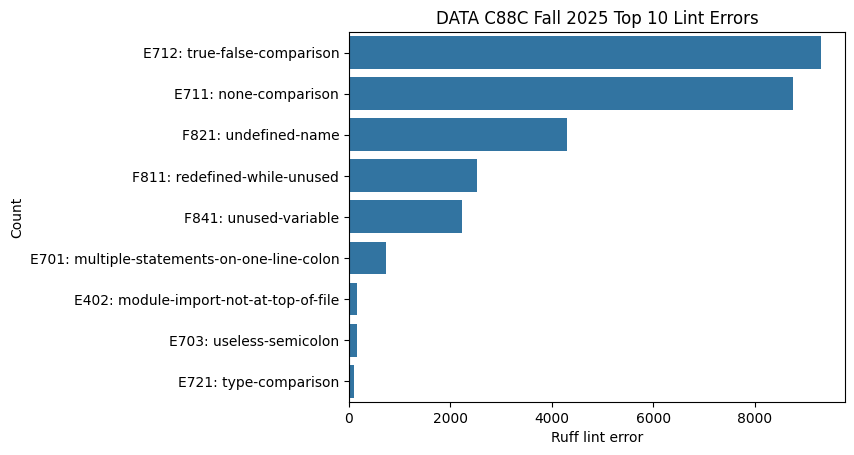

In [181]:
for course, cur in zip(courses, cursors):
    df = results["lint_error_freqs_all_backups"][course].head(10)  # only get top 10
    lint_error_codes = (
        df["code"]
        + ": "
        + df["url"].str.removeprefix("https://docs.astral.sh/ruff/rules/")
    )
    lint_error_counts = df["frequency"]

    sns.barplot(x=lint_error_counts, y=lint_error_codes)
    plt.title(f"{course} Top 10 Lint Errors")
    plt.xlabel("Ruff lint error")
    plt.ylabel("Count")
    plt.show()

## `invalid-syntax` errors

In [ ]:
# TODO once fa25 data re-fetched, look at invalid-syntax errors indicating probable AI usage / copy-paste

## Total number of lint errors in final backup

In [7]:
def total_lint_errors_final_backups(cursor: sqlite3.Cursor) -> np.array:
    # create indexes for faster joins
    cursor.execute(
        "CREATE INDEX IF NOT EXISTS idx_metadata_email_created ON backup_metadata(student_email, created DESC);"
    )
    cursor.execute(
        "CREATE INDEX IF NOT EXISTS idx_lint_location ON lint_errors(file_contents_location);"
    )

    # Create a string of placeholders: (?, ?, ?)
    placeholders = ", ".join(["?"] * len(IGNORED_MESSAGES))

    # Number of lint errors per student on their final backup, excluding errors with ignored messages
    query = f"""
    WITH last_backups AS (
        SELECT
            backup_id,
            MAX(created) AS created, -- in SQLite this works
            student_email,
            file_contents_location
        FROM backup_metadata
        GROUP BY student_email
    ),

    backups_with_lint_errors AS (
        SELECT
            lb.backup_id,
            lb.created,
            lb.student_email,
            le.*
        FROM last_backups AS lb
        JOIN lint_errors AS le
        ON REPLACE(lb.file_contents_location, '../../data/private/', '') = REPLACE(le.file_contents_location, '/ants.py', '')
        WHERE message NOT IN ({placeholders})
    )

    SELECT
        student_email,
        COUNT(*)
    FROM backups_with_lint_errors
    GROUP BY student_email
    ORDER BY COUNT(*) DESC
    """
    cursor.execute(query, IGNORED_MESSAGES)
    return np.array([row[1] for row in cursor.fetchall()])

**Note: The cell below takes a significantly long time to run, ~21 min**

In [10]:
results["total_lint_errors_final_backups"] = {}

for course, cur in zip(courses, cursors):
    results["total_lint_errors_final_backups"][course] = (
        total_lint_errors_final_backups(cur)
    )

<Axes: ylabel='Count'>

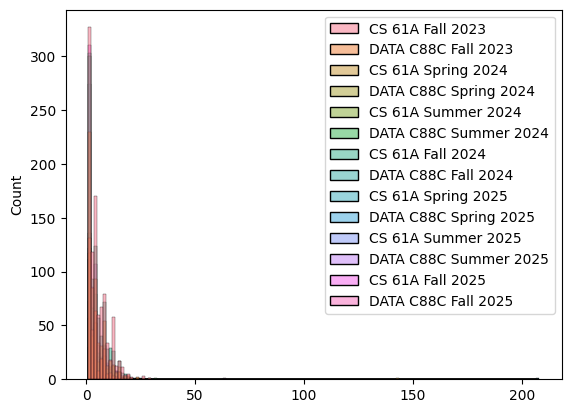

In [13]:
sns.histplot(data=results["total_lint_errors_final_backups"])

<Axes: ylabel='Count'>

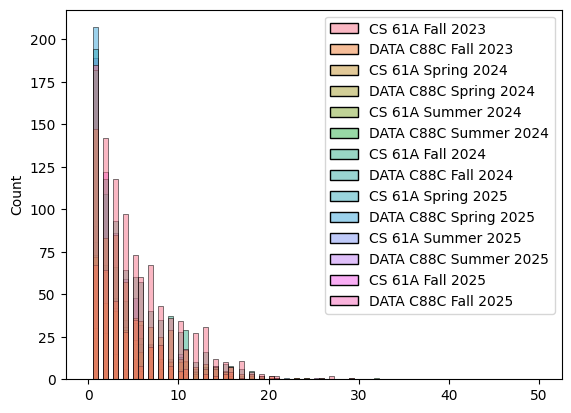

In [15]:
sns.histplot(data=results["total_lint_errors_final_backups"], binrange=(0, 50))

<Axes: ylabel='Count'>

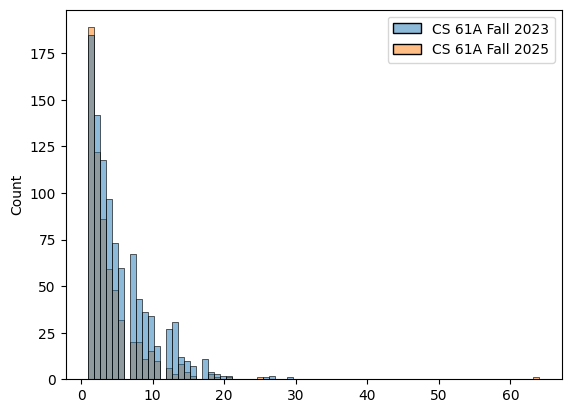

In [16]:
sns.histplot(
    data={
        key: val
        for key, val in results["total_lint_errors_final_backups"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and key.cs61a
    },
)

<Axes: ylabel='Count'>

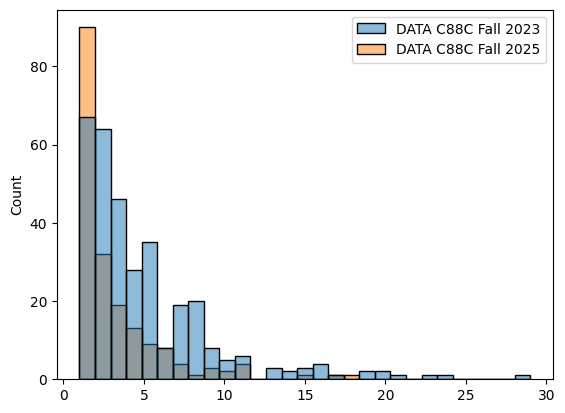

In [17]:
sns.histplot(
    data={
        key: val
        for key, val in results["total_lint_errors_final_backups"].items()
        if (key.year == 2023 or (key.year == 2025 and key.term == Term.FALL))
        and not key.cs61a
    },
)

In [18]:
median_tlefb = {
    "Course": [],
    "Term": [],
    "Median total lint errors in final backup": [],
}

for course, cur in zip(courses, cursors):
    median_tlefb["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    median_tlefb["Term"].append(course.term_string.upper())
    median_tlefb["Median total lint errors in final backup"].append(
        np.median(results["total_lint_errors_final_backups"][course])
    )

median_tlefb = pd.DataFrame.from_dict(median_tlefb)

<Axes: xlabel='Term', ylabel='Median total lint errors in final backup'>

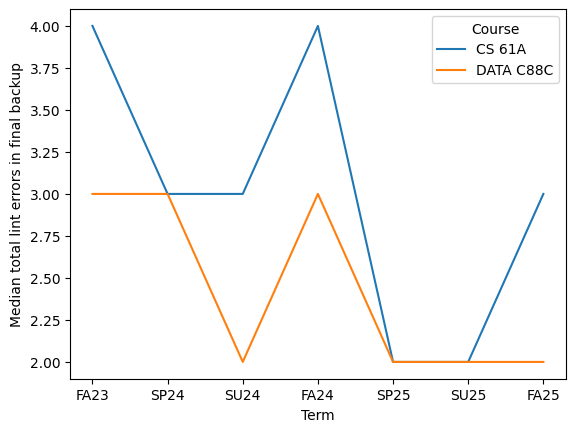

In [20]:
sns.lineplot(
    data=median_tlefb,
    x="Term",
    y="Median total lint errors in final backup",
    hue="Course",
)

## Top error codes in final backup

In [ ]:
def lint_error_freqs_final_backup(cursor: sqlite3.Cursor) -> pd.DataFrame:
    # create indexes for faster joins
    cursor.execute(
        "CREATE INDEX IF NOT EXISTS idx_metadata_email_created ON backup_metadata(student_email, created DESC);"
    )
    cursor.execute(
        "CREATE INDEX IF NOT EXISTS idx_lint_location ON lint_errors(file_contents_location);"
    )

    # Create a string of placeholders: (?, ?, ?)
    placeholders = ", ".join(["?"] * len(IGNORED_MESSAGES))

    # Number of lint errors per student on their final backup, excluding errors with ignored messages
    query = f"""
    WITH last_backups AS (
        SELECT
            backup_id,
            MAX(created) AS created, -- in SQLite this works
            student_email,
            file_contents_location
        FROM backup_metadata
        GROUP BY student_email
    ),

    backups_with_lint_errors AS (
        SELECT
            lb.backup_id,
            le.*
        FROM last_backups AS lb
        JOIN lint_errors AS le
        ON REPLACE(lb.file_contents_location, '../../data/private/', '') = REPLACE(le.file_contents_location, '/ants.py', '')
        WHERE message NOT IN ({placeholders})
    )

    SELECT
        code,
        url,
        COUNT(*) AS frequency
    FROM backups_with_lint_errors
    GROUP BY code, url
    ORDER BY COUNT(*) DESC
    LIMIT 10
    """
    cursor.execute(query, IGNORED_MESSAGES)
    columns = [column[0] for column in cursor.description]
    return pd.DataFrame(cursor.fetchall(), columns=columns)

**Note: This cell below takes ~20 min**

In [22]:
results["lint_error_freqs_final_backup"] = {}

for course, cur in zip(courses, cursors):
    results["lint_error_freqs_final_backup"][course] = lint_error_freqs_final_backup(
        cur
    )

14it [20:31, 87.97s/it]


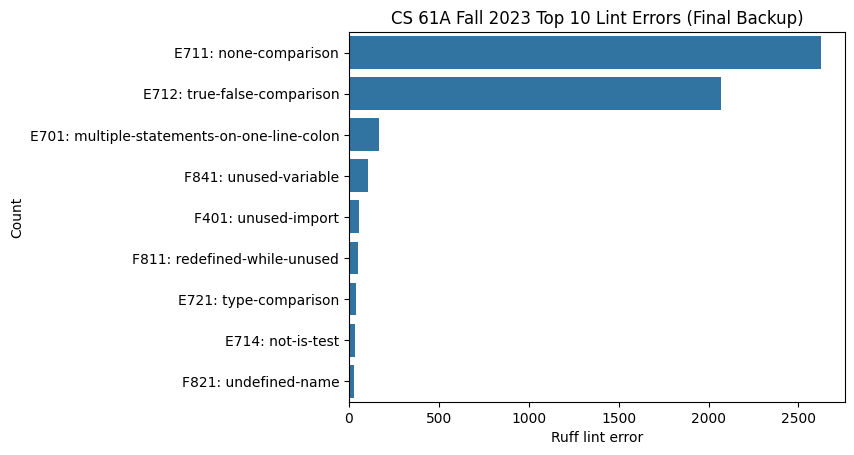

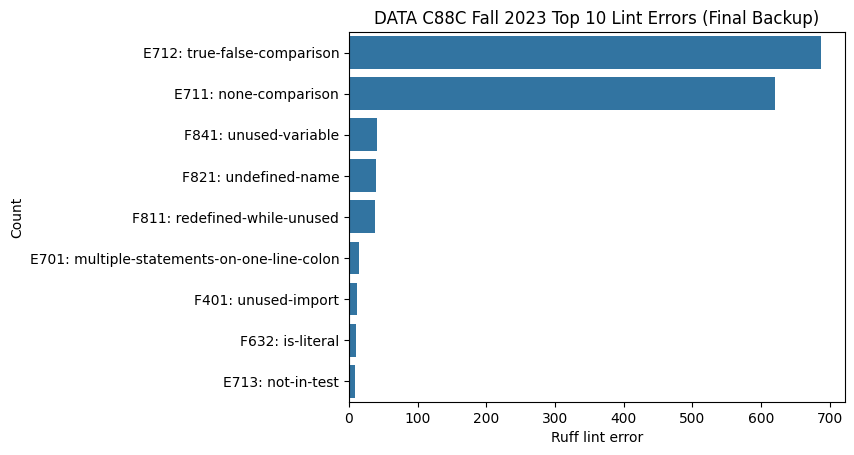

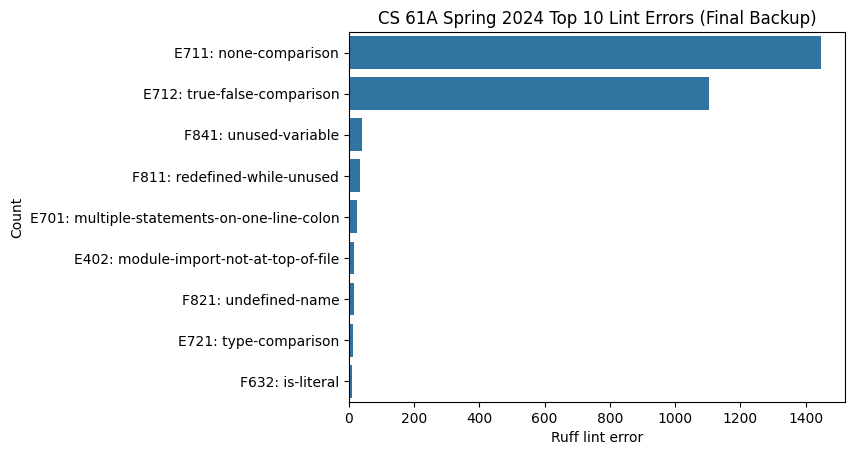

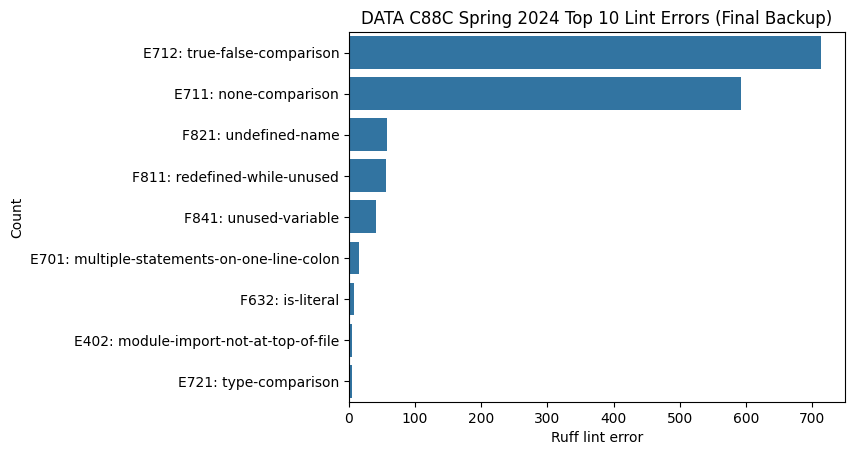

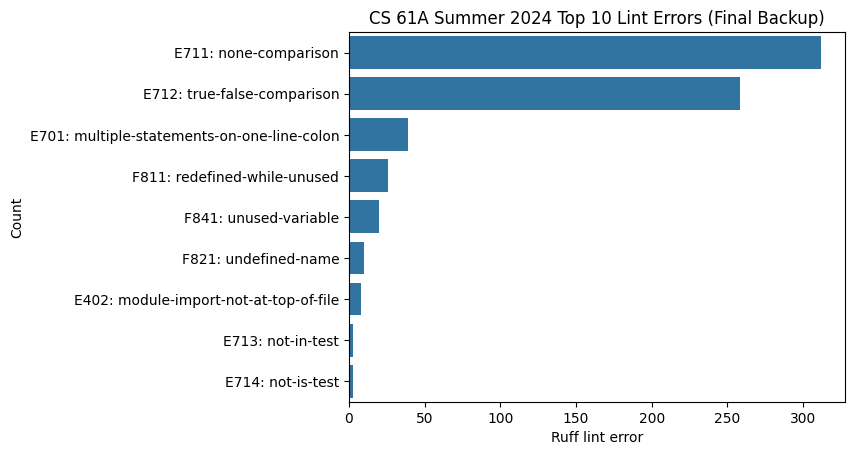

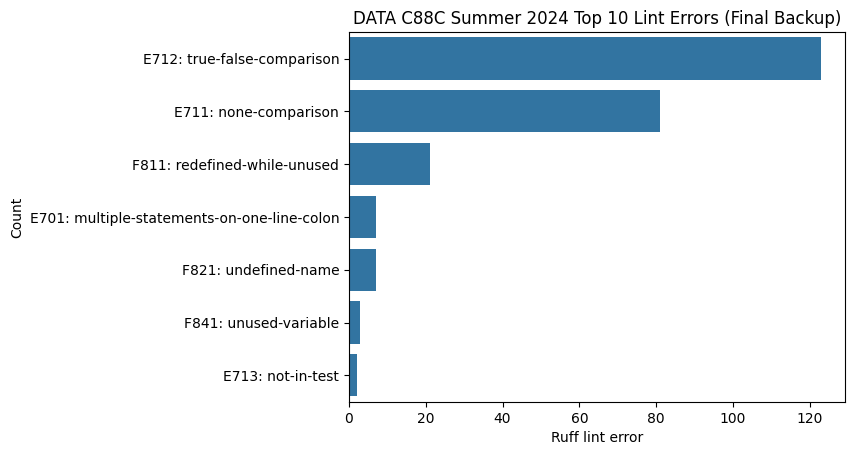

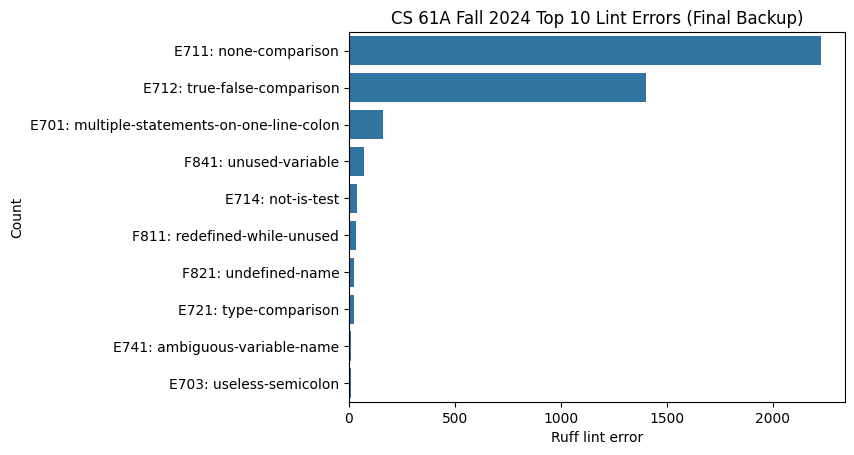

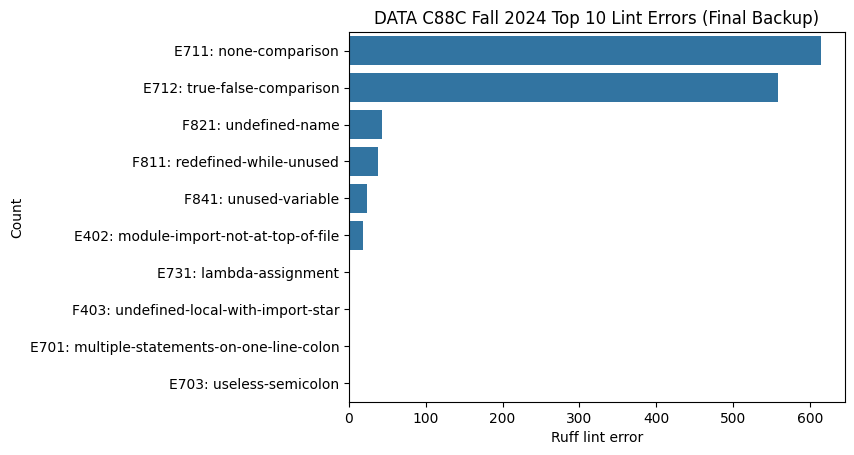

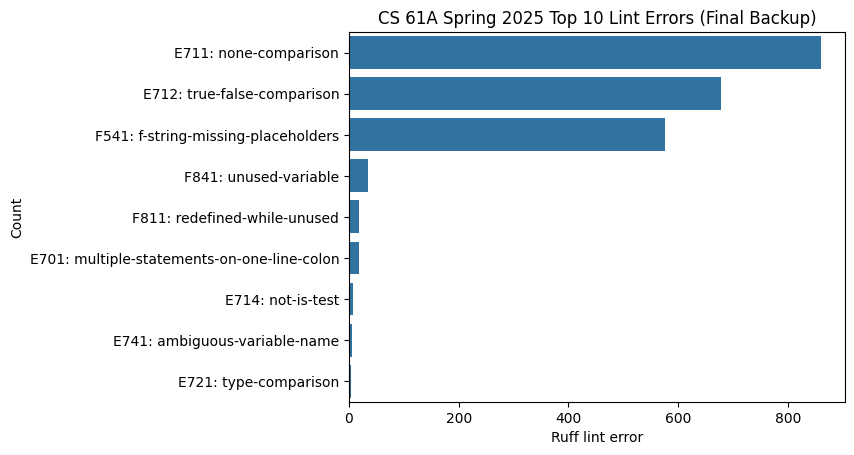

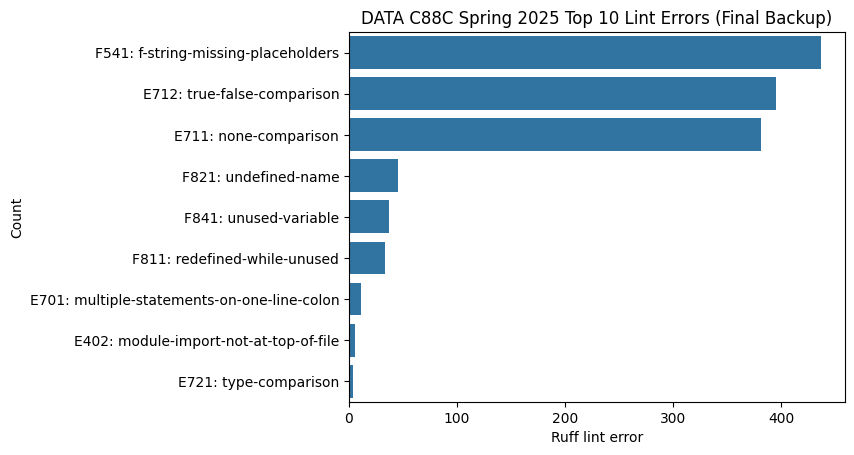

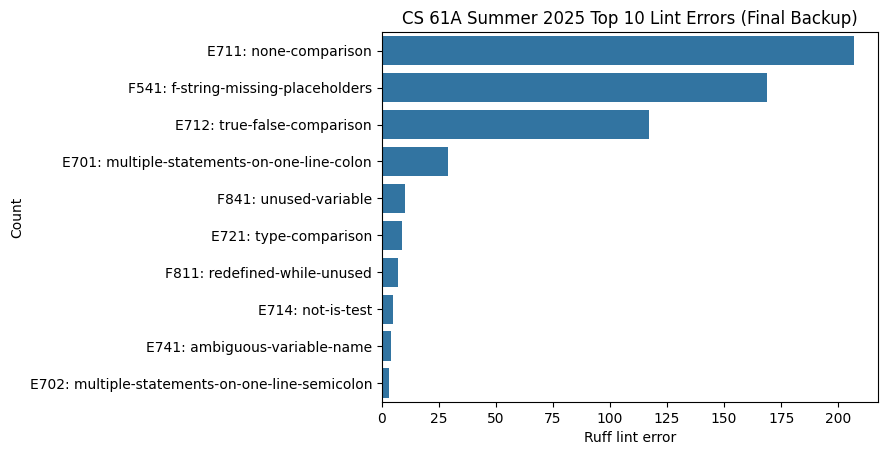

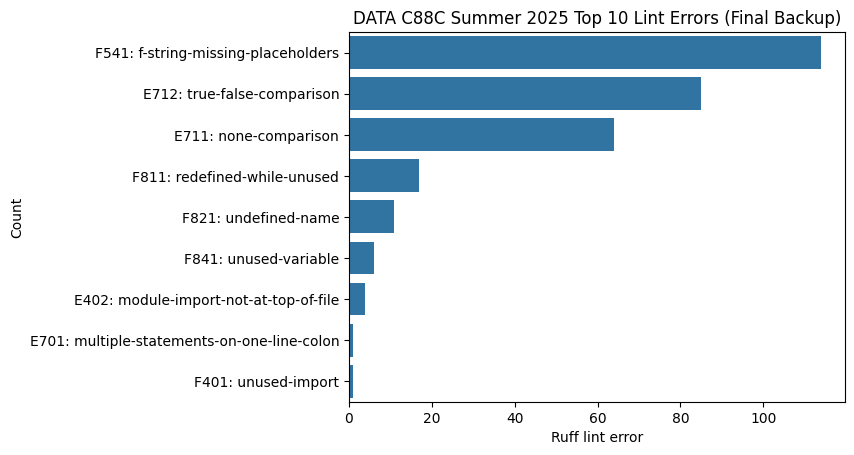

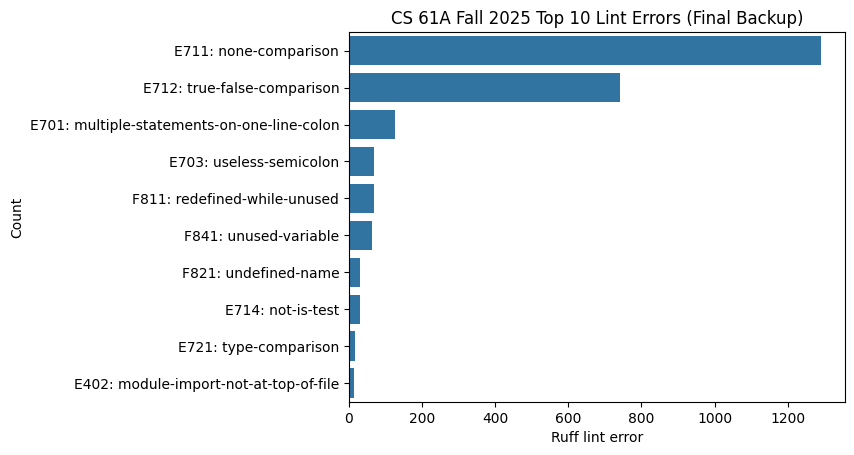

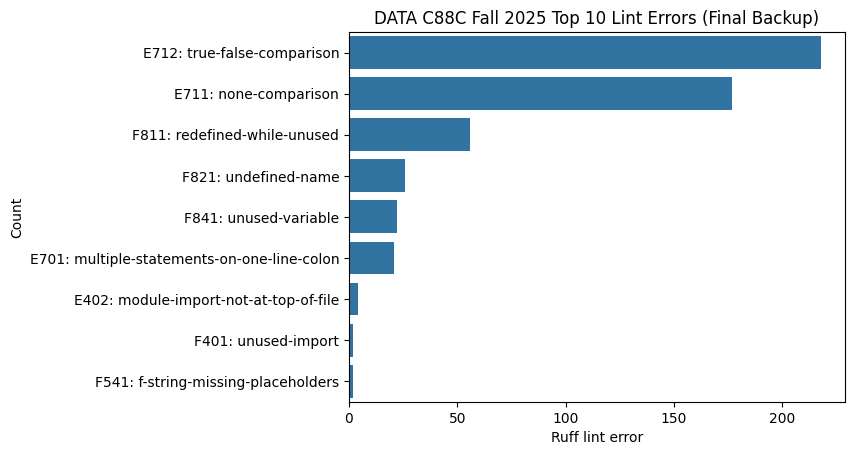

In [ ]:
for course, cur in zip(courses, cursors):
    df = results["lint_error_freqs_final_backup"][course]
    lint_error_codes = (
        df["code"]
        + ": "
        + df["url"].str.removeprefix("https://docs.astral.sh/ruff/rules/")
    )
    lint_error_counts = df["frequency"]

    sns.barplot(x=lint_error_counts, y=lint_error_codes)
    plt.title(f"{course} Top 10 Lint Errors (Final Backup)")
    plt.xlabel("Ruff lint error")
    plt.ylabel("Count")
    plt.show()

## Analysis by problem

In [109]:
def get_backups_with_analytics(cursor: sqlite3.Cursor) -> list[sqlite3.Row]:
    cursor.execute("""
    SELECT
        bm.backup_id,
        unixepoch(bm.created),
        bm.course,
        bm.assignment,
        bm.student_email,
        am.unlock,
        am.question_cli_names
    FROM backup_metadata AS bm
    JOIN analytics_messages AS am
    ON bm.backup_id = am.backup_id
    ORDER BY bm.student_email, bm.created
    """)
    return cursor.fetchall()

In [110]:
# ignore EC problems and collapse Q8a, b, c into Q8
REQUIRED_PROBLEM_CLI_NAMES = [f"{n:02}" for n in range(0, 13)]


def get_backups_per_problem(backups_with_analytics: list[sqlite3.Row]):
    # Internal map: prob_name -> { student_email: count }
    # We use a nested dict to track counts per student for each specific problem
    temp_counts = {prob_name: {} for prob_name in REQUIRED_PROBLEM_CLI_NAMES}

    for backup in backups_with_analytics:
        backup = tuple(backup)
        (
            backup_id,
            created,
            course,
            assignment,
            student_email,
            unlock,
            question_cli_names,
        ) = backup

        questions = json.loads(question_cli_names)

        if questions is None:
            continue

        for prob_name in questions:
            if prob_name.startswith("08"):
                prob_name = "08"

            # Increment the specific student's count for this problem
            if prob_name in temp_counts:
                student_counts = temp_counts[prob_name]
                student_counts[student_email] = student_counts.get(student_email, 0) + 1

    # Convert the per-student dictionaries into lists of counts
    # Resulting shape: { "01": [count_student_A, count_student_B, ...], ... }
    problem_to_backups_per_student = {
        prob_name: list(counts.values()) for prob_name, counts in temp_counts.items()
    }

    return problem_to_backups_per_student

In [111]:
results["backups_per_problem"] = {}

for course, cur in zip(courses, cursors):
    backups_with_analytics = get_backups_with_analytics(cur)
    results["backups_per_problem"][course] = get_backups_per_problem(
        backups_with_analytics
    )

In [171]:
def plot_median_backups_over_time(backups_per_problem: dict):
    plot_data = []

    for course, problem_map in backups_per_problem.items():
        # course_obj is an instance of the Course class
        # problem_map is { "01": [5, 8, ...], "02": [...] }

        for prob_name, counts in problem_map.items():
            plot_data.append(
                {
                    "Course Name": "CS 61A" if course.cs61a else "DATA C88C",
                    "Term": course.term_string.upper(),
                    "Year": course.year,
                    "TermOrder": course.term.value,  # For chronological sorting
                    "Problem": prob_name,
                    "Median Backups": np.median(counts),
                    "p25": np.percentile(counts, 25),
                    "p75": np.percentile(counts, 75),
                }
            )

    df = pd.DataFrame(plot_data)

    # Sort chronologically by Year then Term Enum value
    df = df.sort_values(["Year", "TermOrder"])

    # Use seaborn colorblind palette defined at top of notebook, but don't use blue/orange
    # since that's reserved for differentiating between courses
    problem_colors = {"08": palette[2], "12": palette[3]}

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for i, course_name in enumerate(["CS 61A", "DATA C88C"]):
        course_df = df[(df["Course Name"] == course_name) & (df["Problem"].isin(problem_colors.keys()))]

        # Plot median
        sns.lineplot(
            data=course_df,
            x="Term",
            y="Median Backups",
            hue="Problem",
            marker="o",
            palette=problem_colors,
            ax=axes[i],
        )

        # Plot IQR
        for problem, color in problem_colors.items():
            prob_df = course_df[course_df["Problem"] == problem]
            axes[i].fill_between(
                prob_df["Term"],
                prob_df["p25"],
                prob_df["p75"],
                color=color,
                alpha=0.2,
            )

        if i == 0:
            axes[i].set_title(f"(a) {course_name}")
        else:
            axes[i].set_title(f"(b) {course_name}")

        axes[i].set_ylim((0, 45)) # force same y limits for easier comparison
        axes[i].set_ylabel("Backups")
        axes[i].grid(axis="y", linestyle="--", alpha=0.7)

        # Share legend
        if i == 1:
            axes[i].legend(title="Problem", bbox_to_anchor=(1.05, 1), loc="upper left")
        else:
            axes[i].get_legend().remove()

    fig.suptitle("Median Backups Per Problem")
    plt.show()

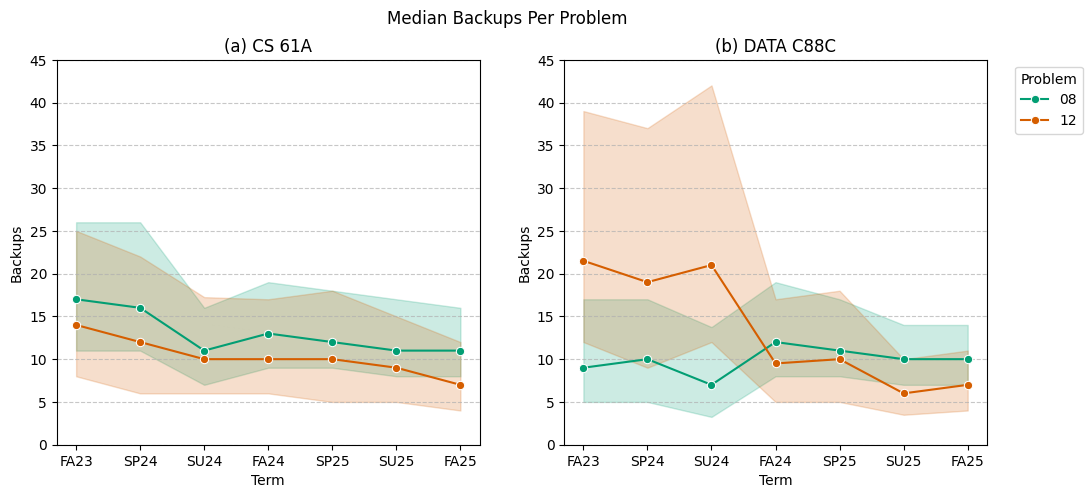

In [172]:
plot_median_backups_over_time(results["backups_per_problem"])

### Group by problem and worksession

In [173]:
def group_by_problem_worksession(
    backups_with_analytics: list[sqlite3.Row],
    threshold_sec: int = 30 * 60,  # 30 min
) -> dict[str, list[list[tuple]]]:
    result = defaultdict(list)

    prev_student_email = None
    prev_question_cli_names = None
    prev_created = None

    for backup in backups_with_analytics:
        backup = tuple(backup)
        (
            backup_id,
            created,
            course,
            assignment,
            student_email,
            unlock,
            question_cli_names,
        ) = backup

        if (
            (prev_student_email is None or prev_student_email != student_email)
            or (
                prev_question_cli_names is None
                or prev_question_cli_names != question_cli_names
            )
            or (prev_created is None or (created - prev_created > threshold_sec))
        ):
            result[student_email].append([backup])
        else:
            group_index = len(result[student_email]) - 1
            curr_group = result[student_email][group_index]
            curr_group.append(backup)

        prev_student_email = student_email
        prev_question_cli_names = question_cli_names
        prev_created = created

    return result

In [174]:
def get_worksessions_per_student(grouped: dict[str, list[list[tuple]]]) -> np.array:
    result = []
    for student, worksessions in grouped.items():
        num_worksessions = len(worksessions)
        result.append(num_worksessions)
    return np.array(result)

In [175]:
results["worksessions_per_student"] = {}

for course, cur in zip(courses, cursors):
    backups_with_analytics = get_backups_with_analytics(cur)
    grouped = group_by_problem_worksession(backups_with_analytics)
    results["worksessions_per_student"][course] = get_worksessions_per_student(grouped)

In [178]:
median_wps = {
    "Course": [],
    "Term": [],
    "Median worksessions per student": [],
    "p25": [],
    "p75": [],
}

for course, cur in zip(courses, cursors):
    median_wps["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    median_wps["Term"].append(course.term_string.upper())
    median_wps["Median worksessions per student"].append(
        np.median(results["worksessions_per_student"][course])
    )
    median_wps["p25"].append(
        np.percentile(results["worksessions_per_student"][course], 25)
    )
    median_wps["p75"].append(
        np.percentile(results["worksessions_per_student"][course], 75)
    )

mwps_df = pd.DataFrame.from_dict(median_wps)

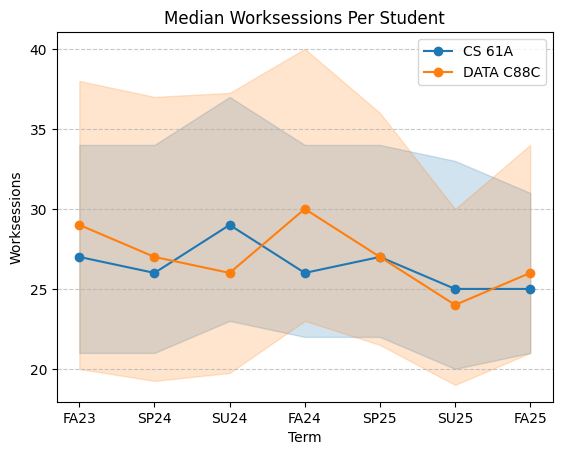

In [180]:
for course_name in mwps_df["Course"].unique():
    course_df = mwps_df[mwps_df["Course"] == course_name]

    # Plot median line
    (line,) = plt.plot(
        course_df["Term"],
        course_df["Median worksessions per student"],
        marker="o",
        label=f"{course_name}",
    )

    # Plot IQR
    plt.fill_between(
        course_df["Term"],
        course_df["p25"],
        course_df["p75"],
        color=line.get_color(),
        alpha=0.2,
    )

plt.title("Median Worksessions Per Student")
plt.xlabel("Term")
plt.ylabel("Worksessions")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [181]:
def get_avg_worksession_length_per_student(
    grouped: dict[str, list[list[tuple]]],
) -> np.array:
    result = []
    for student, worksessions in grouped.items():
        total_lengths = 0
        for session in worksessions:
            total_lengths += len(session)
        result.append(total_lengths / len(worksessions))
    return np.array(result)

In [182]:
results["worksession_length_per_student"] = {}

for course, cur in zip(courses, cursors):
    backups_with_analytics = get_backups_with_analytics(cur)
    grouped = group_by_problem_worksession(backups_with_analytics)
    results["worksession_length_per_student"][course] = (
        get_avg_worksession_length_per_student(grouped)
    )

In [184]:
median_wlps = {
    "Course": [],
    "Term": [],
    "Median worksession length per student": [],
    "p25": [],
    "p75": [],
}

for course, cur in zip(courses, cursors):
    median_wlps["Course"].append("CS 61A" if course.cs61a else "DATA C88C")
    median_wlps["Term"].append(course.term_string.upper())
    median_wlps["Median worksession length per student"].append(
        np.median(results["worksession_length_per_student"][course])
    )
    median_wlps["p25"].append(
        np.percentile(results["worksession_length_per_student"][course], 25)
    )
    median_wlps["p75"].append(
        np.percentile(results["worksession_length_per_student"][course], 75)
    )

mwlps_df = pd.DataFrame.from_dict(median_wlps)

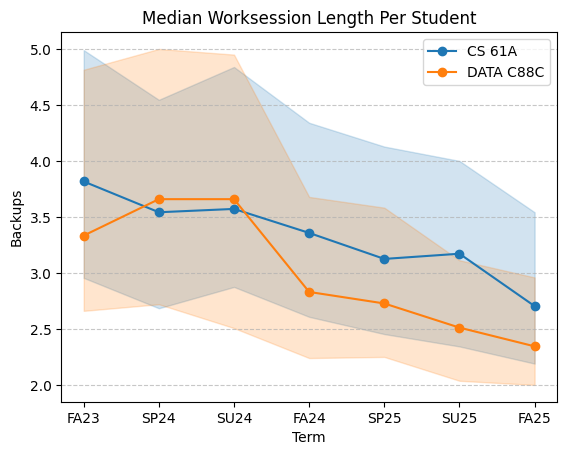

In [185]:
for course_name in mwlps_df["Course"].unique():
    course_df = mwlps_df[mwlps_df["Course"] == course_name]

    # Plot median line
    (line,) = plt.plot(
        course_df["Term"],
        course_df["Median worksession length per student"],
        marker="o",
        label=f"{course_name}",
    )

    # Plot IQR
    plt.fill_between(
        course_df["Term"],
        course_df["p25"],
        course_df["p75"],
        color=line.get_color(),
        alpha=0.2,
    )

plt.title("Median Worksession Length Per Student")
plt.xlabel("Term")
plt.ylabel("Backups")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

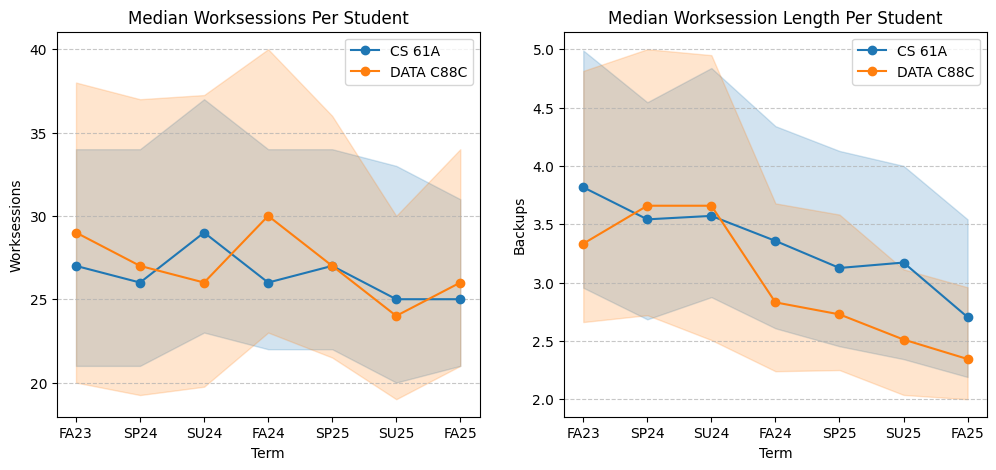

In [195]:
# Combine into subfigure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot (a) Number of worksessions
ax0 = axes[0]
for course_name in mwps_df["Course"].unique():
    course_df = mwps_df[mwps_df["Course"] == course_name]

    # Plot median line
    (line,) = ax0.plot(
        course_df["Term"],
        course_df["Median worksessions per student"],
        marker="o",
        label=f"{course_name}",
    )

    # Plot IQR
    ax0.fill_between(
        course_df["Term"],
        course_df["p25"],
        course_df["p75"],
        color=line.get_color(),
        alpha=0.2,
    )

ax0.set_title("Median Worksessions Per Student")
ax0.set_xlabel("Term")
ax0.set_ylabel("Worksessions")
ax0.legend()
ax0.grid(axis="y", linestyle="--", alpha=0.7)

# Plot (b) Worksession length
ax1 = axes[1]
for course_name in mwlps_df["Course"].unique():
    course_df = mwlps_df[mwlps_df["Course"] == course_name]

    # Plot median line
    (line,) = ax1.plot(
        course_df["Term"],
        course_df["Median worksession length per student"],
        marker="o",
        label=f"{course_name}",
    )

    # Plot IQR
    ax1.fill_between(
        course_df["Term"],
        course_df["p25"],
        course_df["p75"],
        color=line.get_color(),
        alpha=0.2,
    )

ax1.set_title("Median Worksession Length Per Student")
ax1.set_xlabel("Term")
ax1.set_ylabel("Backups")
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

## "Calendar heatmap" barplot equivalent

In [ ]:
# TODO x-axis: relative days into project, y-axis: number of students who worked that day
# TODO ... or use heatmap instead?

## Write results to JSON

In [ ]:
with open("results.json", "w") as f:
    json.dump(results, f)

## Teardown

In [ ]:
# Close db connection
for conn in conns:
    conn.close()